This is a companion notebook for the book [Deep Learning with Python, Third Edition](TODO). For readability, it only contains runnable code blocks and section titles, and omits everything else in the book: text paragraphs, figures, and pseudocode.

**If you want to be able to follow what's going on, I recommend reading the notebook side by side with your copy of the book.**

## Be sure to watch the 3blue1brown videos on neural networks:

https://www.3blue1brown.com/topics/neural-networks

## Also, Welch Labs has some good videos on neural networks:

https://www.youtube.com/playlist?list=PLiaHhY2iBX9hdHaRr6b7XevZtgZRa1PoU

## History of perceptrons:

https://flowingdata.com/2025/02/25/perceptron-algorithm-from-the-1950s-and-its-ties-to-llms/

!pip install keras-nightly keras-hub-nightly --upgrade -q

In [18]:
import os
os.environ["KERAS_BACKEND"] = "jax"

### A first look at a neural network

Let’s look at a concrete example of a neural network that uses the machine learning library Keras to learn to classify handwritten digits. We will use Keras extensively throughout this book. It’s a simple, high-level library that will allow us to stay focused on the concepts we would like to cover.

Unless you already have experience with Keras or similar libraries, you won’t understand everything about this first example right away. That’s fine. In a few sections, we’ll review each element in the example and explain them in detail. So don’t worry if some steps seem arbitrary or look like magic to you! We’ve got to start somewhere.

The problem we’re trying to solve here is to classify grayscale images of handwritten digits (28 × 28 pixels) into their 10 categories (0 through 9). We’ll use the MNIST dataset, a classic in the machine-learning community, which has been around almost as long as the field itself and has been intensively studied. It’s a set of 60,000 training images, plus 10,000 test images, assembled by the National Institute of Standards and Technology (the NIST in MNIST) in the 1980s. You can think of “solving” MNIST as the “Hello World” of deep learning – it’s what you do to verify that your algorithms are working as expected. As you become a machine-learning practitioner, you’ll see MNIST come up over and over again, in scientific papers, blog posts, and so on. You can see some MNIST samples in Figure 2.1.

In [19]:
from keras.datasets import mnist

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

train_images and train_labels form the training set, the data that the model will learn from. The model will then be tested on the test set, test_images and test_labels. The images are encoded as NumPy arrays, and the labels are an array of digits, ranging from 0 to 9. The images and labels have a one-to-one correspondence.

In [20]:
train_images.shape

(60000, 28, 28)

In [21]:
len(train_labels)

60000

In [22]:
train_labels

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

In [23]:
test_images.shape

(10000, 28, 28)

In [24]:
len(test_labels)

10000

In [25]:
test_labels

array([7, 2, 1, ..., 4, 5, 6], dtype=uint8)

The workflow will be as follows: First, we’ll feed the neural network the training data, train_images and train_labels. The network will then learn to associate images and labels. Finally, we’ll ask the network to produce predictions for test_images, and we’ll verify whether these predictions match the labels from test_labels.

Let’s build the network – again, remember that you aren’t expected to understand everything about this example yet.

In [26]:
import keras
from keras import layers

model = keras.Sequential(
    [
        layers.Dense(512, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)

The core building block of neural networks is the layer. You can think of a layer as a filter for data: some data goes in, and it comes out in a more useful form. Specifically, layers extract representations out of the data fed into them – hopefully, representations that are more meaningful for the problem at hand. Most of deep learning consists of chaining together simple layers that will implement a form of progressive data distillation. A deep-learning model is like a sieve for data processing, made of a succession of increasingly refined data filters – the layers.

Here, our model consists of a sequence of two Dense layers, which are densely connected (also called fully connected) neural layers. The second (and last) layer is a 10-way softmax classification layer, which means it will return an array of 10 probability scores (summing to 1). Each score will be the probability that the current digit image belongs to one of our 10 digit classes.

To make the model ready for training, we need to pick three more things, as part of the compilation step:

A loss function – How the model will be able to measure its performance on the training data, and thus how it will be able to steer itself in the right direction.

An optimizer – The mechanism through which the model will update itself based on the training data it sees, so as to improve its performance.

Metrics to monitor during training and testing – Here, we’ll only care about accuracy (the fraction of the images that were correctly classified).

The exact purpose of the loss function and the optimizer will be made clear throughout the next two chapters.

In [27]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

Before training, we’ll preprocess the data by reshaping it into the shape the model expects and scaling it so that all values are in the [0, 1] interval. Previously, our training images were stored in an array of shape (60000, 28, 28) of type uint8 with values in the [0, 255] interval. We transform it into a float32 array of shape (60000, 28 * 28) with values between 0 and 1.

In [28]:
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255
test_images = test_images.reshape((10000, 28 * 28))
test_images = test_images.astype("float32") / 255

In [29]:
model.fit(train_images, train_labels, epochs=5, batch_size=128)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8682 - loss: 0.4614
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9675 - loss: 0.1144
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9786 - loss: 0.0734
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9866 - loss: 0.0466
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9895 - loss: 0.0358


Two quantities are displayed during training: the loss of the model over the training data, and the accuracy of the model over the training data. We quickly reach an accuracy of 0.989 (98.9%) on the training data.

Now that we have a trained model, you can use it to predict class probabilities for new digits – images that weren’t part of the training data, like those from the test set:

In [30]:
test_digits = test_images[0:10]
predictions = model.predict(test_digits)
predictions[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 714ms/step


array([2.8230821e-07, 1.4111339e-07, 1.1013446e-05, 3.0013444e-04,
       1.6706422e-09, 1.3521250e-07, 3.0882016e-11, 9.9967247e-01,
       2.8268228e-06, 1.2901317e-05], dtype=float32)

Each number of index i in that array corresponds to the probability that digit image test_digits[0] belong to class i.

This first test digit has the highest probability score (0.99999106, almost 1) at index 7, so according to our model, it must be a 7:

In [31]:
predictions[0].argmax()

np.int64(7)

In [32]:
predictions[0][7]

np.float32(0.9996725)

In [33]:
test_labels[0]

np.uint8(7)

On average, how good is our model at classifying such never-seen-before digits? Let’s check by computing average accuracy over the entire test set.

The test-set accuracy turns out to be 97.8% – that’s almost double the error rate of the training set (at 98.9% accuracy). This gap between training accuracy and test accuracy is an example of overfitting: the fact that machine-learning models tend to perform worse on new data than on their training data. Overfitting is a central topic in Chapter 5.

In [34]:
test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f"test_acc: {test_acc}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9757 - loss: 0.0771
test_acc: 0.9793999791145325


### Data representations for neural networks

In the previous example, we started from data stored in multidimensional NumPy arrays, also called tensors. In general, all current machine-learning systems use tensors as their basic data structure. Tensors are fundamental to the field – so fundamental that the TensorFlow framework was named after them. So what’s a tensor?

At its core, a tensor is a container for data – usually numerical data. So, it’s a container for numbers. You may be already familiar with matrices, which are rank-2 tensors: tensors are a generalization of matrices to an arbitrary number of dimensions (note that in the context of tensors, a dimension is often called an axis).

Going over the details of tensors might seem a bit abstract at first. But it’s well worth it – manipulating tensors will be the bread and butter of any machine learning code you ever write.

#### Scalars (rank-0 tensors)

In [35]:
import numpy as np
x = np.array(12)
x

array(12)

In [36]:
x.ndim

0

#### Vectors (rank-1 tensors)

In [37]:
x = np.array([12, 3, 6, 14, 7])
x

array([12,  3,  6, 14,  7])

In [38]:
x.ndim

1

#### Matrices (rank-2 tensors)

In [39]:
x = np.array([[5, 78, 2, 34, 0],
              [6, 79, 3, 35, 1],
              [7, 80, 4, 36, 2]])
x.ndim

2

#### Rank-3 tensors and higher-rank tensors

In [40]:
x = np.array([[[5, 78, 2, 34, 0],
               [6, 79, 3, 35, 1],
               [7, 80, 4, 36, 2]],
              [[5, 78, 2, 34, 0],
               [6, 79, 3, 35, 1],
               [7, 80, 4, 36, 2]],
              [[5, 78, 2, 34, 0],
               [6, 79, 3, 35, 1],
               [7, 80, 4, 36, 2]]])
x.ndim

3

#### Key attributes

A tensor is defined by three key attributes:

Number of axes (rank) – For instance, a rank-3 tensor has three axes, and a matrix has two axes. This is also called the tensor’s ndim in Python libraries such as NumPy, JAX, TensorFlow, or PyTorch.

Shape – This is a tuple of integers that describes how many dimensions the tensor has along each axis. For instance, the previous matrix example has shape (3, 5), and the rank-3 tensor example has shape (3, 3, 5). A vector has a shape with a single element, such as (5,), whereas a scalar has an empty shape, ().

Data type (usually called dtype in Python libraries) – This is the type of the data contained in the tensor; for instance, a tensor’s type could be float16, float32, float64, uint8, bool, and so on. In TensorFlow, you are also likely to come across string tensors.

To make this more concrete, let’s look back at the data we processed in the MNIST example. First, we load the MNIST dataset:

In [41]:
from keras.datasets import mnist

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

In [42]:
train_images.ndim

3

In [43]:
train_images.shape

(60000, 28, 28)

In [44]:
train_images.dtype

dtype('uint8')

So what we have here is a rank-3 tensor of 8-bit integers. More precisely, it’s an array of 60,000 matrices of 28 × 28 integers. Each such matrix is a grayscale image, with coefficients between 0 and 255.

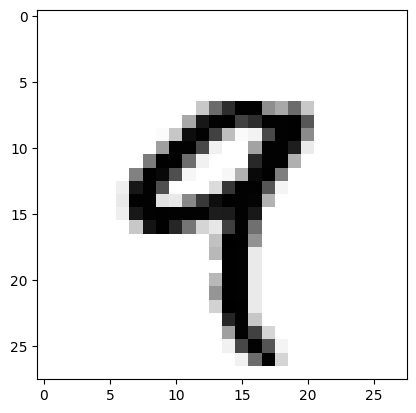

In [45]:
import matplotlib.pyplot as plt

digit = train_images[4]
plt.imshow(digit, cmap=plt.cm.binary)
plt.savefig("The-fourth-sample-in-our-dataset.png", dpi=300)

In [46]:
train_labels[4]

np.uint8(9)

#### Manipulating tensors in NumPy

The following example selects digits #10 to #100 (#100 isn’t included) and puts them in an array of shape (90, 28, 28):

In [47]:
my_slice = train_images[10:100]
my_slice.shape

(90, 28, 28)

In [48]:
my_slice = train_images[10:100, :, :]
my_slice.shape

(90, 28, 28)

In [49]:
my_slice = train_images[10:100, 0:28, 0:28]
my_slice.shape

(90, 28, 28)

In [50]:
my_slice = train_images[:, 14:, 14:]

In [51]:
my_slice = train_images[:, 7:-7, 7:-7]

#### The notion of data batches

In [52]:
batch = train_images[:128]

In [53]:
batch = train_images[128:256]

In [54]:
n = 3
batch = train_images[128 * n : 128 * (n + 1)]

#### Real-world examples of data tensors

Let’s make data tensors more concrete with a few examples similar to what you’ll encounter later. The data you’ll manipulate will almost always fall into one of the following categories:

Vector data – rank-2 tensors of shape (samples, features), where each sample is a vector of numerical attributes (“features”).

Timeseries data or sequence data – rank-3 tensors of shape (samples, timesteps, features), where each sample is a sequence (of length timesteps) of feature vectors.

Images – rank-4 tensors of shape (samples, height, width, channels), where each sample is a 2D grid of pixels, and each pixel is represented by a vector of values (“channels”).

Video – rank-5 tensors of shape (samples, frames, height, width, channels), where each sample is a sequence (of length frames) of images.

##### Vector data

This is one of the most common cases. In such a dataset, each single data point can be encoded as a vector, and thus a batch of data will be encoded as a rank-2 tensor (that is, an array of vectors), where the first axis is the samples axis and the second axis is the features axis.

Let’s take a look at two examples:

An actuarial dataset of people, where we consider each person’s age, gender, and income. Each person can be characterized as a vector of 3 values, and thus an entire dataset of 100,000 people can be stored in a rank-2 tensor of shape (100000, 3).

A dataset of text documents, where we represent each document by the counts of how many times each word appears in it (out of a dictionary of 20,000 common words). Each document can be encoded as a vector of 20,000 values (one count per word in the dictionary), and thus an entire dataset of 500 documents can be stored in a tensor of shape (500, 20000).

##### Timeseries data or sequence data

Whenever time matters in your data (or the notion of sequence order), it makes sense to store it in a rank-3 tensor with an explicit time axis. Each sample can be encoded as a sequence of vectors (a rank-2 tensor), and thus a batch of data will be encoded as a rank-3 tensor (see Figure 2.3).

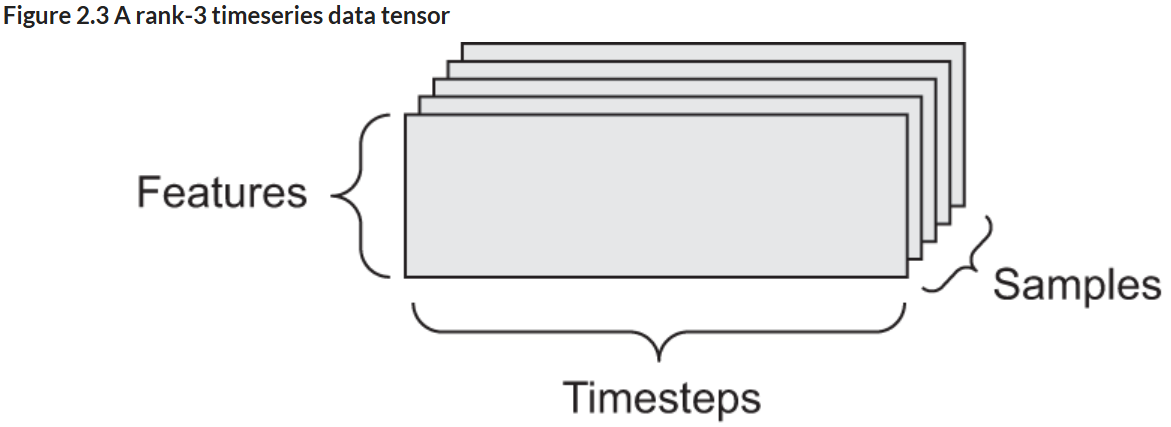

The time axis is always the second axis (axis of index 1), by convention. Let’s look at a few examples:

A dataset of stock prices. Every minute, we store the current price of the stock, the highest price in the past minute, and the lowest price in the past minute. Thus every minute is encoded as a 3D vector, an entire day of trading is encoded as a matrix of shape (390, 3) (there are 390 minutes in a trading day), and 250 days’ worth of data can be stored in a rank-3 tensor of shape (250, 390, 3). Here, each sample would be one day’s worth of data.

A dataset of tweets, where we encode each tweet as a sequence of 280 characters out of an alphabet of 128 unique characters. In this setting, each character can be encoded as a binary vector of size 128 (an all-zeros vector except for a 1 entry at the index corresponding to the character). Then each tweet can be encoded as a rank-2 tensor of shape (280, 128), and a dataset of 1 million tweets can be stored in a tensor of shape (1000000, 280, 128).

##### Image data

Images typically have three dimensions: height, width, and color depth. Although grayscale images (like our MNIST digits) have only a single color channel and could thus be stored in rank-2 tensors, by convention image tensors are always rank-3, with a one-dimensional color channel for grayscale images. A batch of 128 grayscale images of size 256 × 256 could thus be stored in a tensor of shape (128, 256, 256, 1), and a batch of 128 color images could be stored in a tensor of shape (128, 256, 256, 3) (see Figure 2.4).

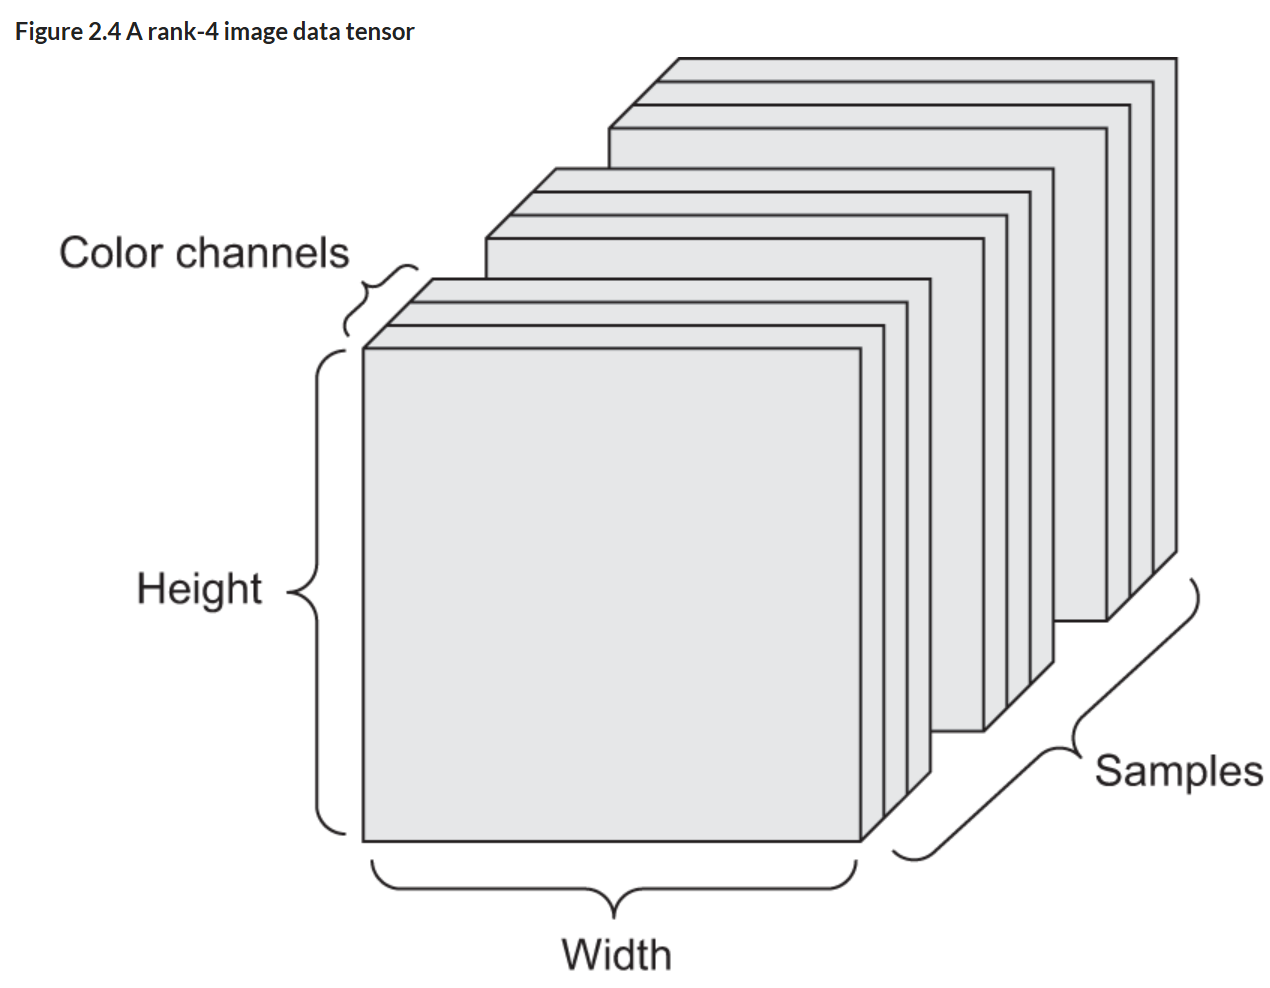

There are two conventions for shapes of image tensors: the channels-last convention (which is standard in JAX and TensorFlow, as well as most other deep learning tools out there), and the channels-first convention (which is standard in PyTorch).

The channels-last convention places the color-depth axis at the end: (samples, height, width, color_depth). Meanwhile, the channels-first convention places the color depth axis right after the batch axis: (samples, color_depth, height, width). With the channels-first convention, the previous examples would become (128, 1, 256, 256) and (128, 3, 256, 256). The Keras API provides support for both formats.

##### Video data

Video data is one of the few types of real-world data for which you’ll need rank-5 tensors. A video can be understood as a sequence of frames, each frame being a color image. Because each frame can be stored in a rank-3 tensor (height, width, color_depth), a sequence of frames can be stored in a rank-4 tensor (frames, height, width, color_depth), and thus a batch of different videos can be stored in a rank-5 tensor of shape (samples, frames, height, width, color_depth).

For instance, a 60-second, 144 × 256 YouTube video clip sampled at 4 frames per second would have 240 frames. A batch of four such video clips would be stored in a tensor of shape (4, 240, 144, 256, 3). That’s a total of 106,168,320 values! If the dtype of the tensor was float32, then each value would be stored in 32 bits, so the tensor would represent 425 MB. Heavy! Videos you encounter in real life are much lighter, because they aren’t stored in float32, and they’re typically compressed by a large factor (such as the MPEG format).

### The gears of neural networks: tensor operations

Just like any computer program can be ultimately reduced to a small set of binary operations on binary inputs (AND, OR, NOR, and so on), all transformations learned by deep neural networks can be reduced to a handful of tensor operations (or tensor functions) applied to tensors of numeric data. For instance, it’s possible to add tensors, multiply tensors, and so on.

In our initial example, we were building our model by stacking Dense layers on top of each other. A Keras layer instance looks like this:

keras.layers.Dense(512, activation="relu")

This layer can be interpreted as a function, which takes as input a matrix and returns another matrix – a new representation for the input tensor. Specifically, the function is as follows (where W is a matrix and b is a vector, both attributes of the layer):

output = relu(matmul(input, W) + b)

Let’s unpack this. We have three tensor operations here:

A tensor product (matmul) between the input tensor and a tensor named W

An addition (+) between the resulting matrix and a vector b

A relu operation: relu(x) is max(x, 0). “relu” stands for “REctified Linear Unit”.

#### Element-wise operations

The relu operation and addition are element-wise operations: operations that are applied independently to each entry in the tensors being considered. This means these operations are highly amenable to massively parallel implementations (vectorized implementations, a term that comes from the vector processor supercomputer architecture from the 1970–1990 period). If you want to write a naive Python implementation of an element-wise operation, you use a for loop, as in this naive implementation of an element-wise relu operation:

In [55]:
def naive_relu(x):
    assert len(x.shape) == 2
    x = x.copy()
    for i in range(x.shape[0]):
        for j in range(x.shape[1]):
            x[i, j] = max(x[i, j], 0)
    return x

In [56]:
def naive_add(x, y):
    assert len(x.shape) == 2
    assert x.shape == y.shape
    x = x.copy()
    for i in range(x.shape[0]):
        for j in range(x.shape[1]):
            x[i, j] += y[i, j]
    return x

In [57]:
import time

x = np.random.random((20, 100))
y = np.random.random((20, 100))

t0 = time.time()
for _ in range(1000):
    z = x + y
    z = np.maximum(z, 0.0)
print("Took: {0:.2f} s".format(time.time() - t0))

Took: 0.03 s


In [58]:
t0 = time.time()
for _ in range(1000):
    z = naive_add(x, y)
    z = naive_relu(z)
print("Took: {0:.2f} s".format(time.time() - t0))

Took: 2.74 s


On the same principle, you can do element-wise multiplication, subtraction, and so on.

In practice, when dealing with NumPy arrays, these operations are available as well-optimized built-in NumPy functions, which themselves delegate the heavy lifting to a Basic Linear Algebra Subprograms (BLAS) implementation. BLAS are low-level, highly parallel, efficient tensor-manipulation routines that are typically implemented in Fortran or C.

So, in NumPy, you can do the following element-wise operation, and it will be blazing fast:

#### Broadcasting

https://numpy.org/doc/stable/user/basics.broadcasting.html


Our earlier naive implementation of naive_add only supports the addition of rank-2 tensors with identical shapes. But in the Dense layer introduced earlier, we added a rank-2 tensor with a vector. What happens with addition when the shapes of the two tensors being added differ?

When possible, and if there’s no ambiguity, the smaller tensor will be broadcasted to match the shape of the larger tensor. Broadcasting consists of two steps:

Axes (called broadcast axes) are added to the smaller tensor to match the ndim of the larger tensor.
The smaller tensor is repeated alongside these new axes to match the full shape of the larger tensor.
Let’s look at a concrete example. Consider X with shape (32, 10) and y with shape (10,):

In [59]:
import numpy as np

X = np.random.random((32, 10))
y = np.random.random((10,))

In [60]:
y = np.expand_dims(y, axis=0)

Then, we repeat y 32 times alongside this new axis, so that we end up with a tensor Y with shape (32, 10), where Y[i, :] == y for i in range(0, 32):

In [61]:
Y = np.tile(y, (32, 1))

At this point, we can proceed to add X and Y, because they have the same shape.

In terms of implementation, no new rank-2 tensor is created, because that would be terribly inefficient. The repetition operation is entirely virtual: it happens at the algorithmic level rather than at the memory level. But thinking of the vector being repeated 32 times alongside a new axis is a helpful mental model. Here’s what a naive implementation would look like:

In [62]:
def naive_add_matrix_and_vector(x, y):
    assert len(x.shape) == 2
    assert len(y.shape) == 1
    assert x.shape[1] == y.shape[0]
    x = x.copy()
    for i in range(x.shape[0]):
        for j in range(x.shape[1]):
            x[i, j] += y[j]
    return x

With broadcasting, you can generally apply two-tensor element-wise operations if one tensor has shape (a, b, … n, n + 1, … m) and the other has shape (n, n + 1, … m). The broadcasting will then automatically happen for axes a through n - 1.

The following example applies the element-wise maximum operation to two tensors of different shapes via broadcasting:

In [63]:
import numpy as np

x = np.random.random((64, 3, 32, 10))
y = np.random.random((32, 10))
z = np.maximum(x, y)

On the same principle, you can do element-wise multiplication, subtraction, and so on.

In practice, when dealing with NumPy arrays, these operations are available as well-optimized built-in NumPy functions, which themselves delegate the heavy lifting to a Basic Linear Algebra Subprograms (BLAS) implementation. BLAS are low-level, highly parallel, efficient tensor-manipulation routines that are typically implemented in Fortran or C.

So, in NumPy, you can do the following element-wise operation, and it will be blazing fast:

#### Tensor product

The tensor product, also called dot product or matmul (short for “matrix multiplication”) is one of the most common, most useful tensor operations.

In NumPy, a tensor product is done using the np.matmul function, and in Keras, with the keras.ops.matmul function. Its shorthand is the @ operator in Python.

In [64]:
x = np.random.random((32,))
y = np.random.random((32,))

z = np.matmul(x, y)
z = x @ y

Mathematically, what does the matmul operation do? Let’s start with the product of two vectors x and y. It’s computed as follows:

In [65]:
def naive_vector_product(x, y):
    assert len(x.shape) == 1
    assert len(y.shape) == 1
    assert x.shape[0] == y.shape[0]
    z = 0.0
    for i in range(x.shape[0]):
        z += x[i] * y[i]
    return z

You’ll have noticed that the product between two vectors is a scalar and that only vectors with the same number of elements are compatible for this operation.

You can also take the product between a matrix x and a vector y, which returns a vector where the coefficients are the products between y and the rows of x. You implement it as follows:

In [66]:
def naive_matrix_vector_product(x, y):
    assert len(x.shape) == 2
    assert len(y.shape) == 1
    assert x.shape[1] == y.shape[0]
    z = np.zeros(x.shape[0])
    for i in range(x.shape[0]):
        for j in range(x.shape[1]):
            z[i] += x[i, j] * y[j]
    return z

In [67]:
def naive_matrix_vector_product(x, y):
    z = np.zeros(x.shape[0])
    for i in range(x.shape[0]):
        z[i] = naive_vector_product(x[i, :], y)
    return z

You could also reuse the code we wrote previously, which highlights the relationship between a matrix-vector product and a vector product:

In [68]:
def naive_matrix_product(x, y):
    assert len(x.shape) == 2
    assert len(y.shape) == 2
    assert x.shape[1] == y.shape[0]
    z = np.zeros((x.shape[0], y.shape[1]))
    for i in range(x.shape[0]):
        for j in range(y.shape[1]):
            row_x = x[i, :]
            column_y = y[:, j]
            z[i, j] = naive_vector_product(row_x, column_y)
    return z

Note that as soon as one of the two tensors has an ndim greater than 1, matmul is no longer symmetric, which is to say that matmul(x, y) isn’t the same as matmul(y, x).

Of course, a tensor product generalizes to tensors with an arbitrary number of axes. The most common applications may be the product between two matrices. You can take the product of two matrices x and y (matmul(x, y)) if and only if x.shape[1] == y.shape[0]. The result is a matrix with shape (x.shape[0], y.shape[1]), where the coefficients are the vector products between the rows of x and the columns of y. Here’s the naive implementation:

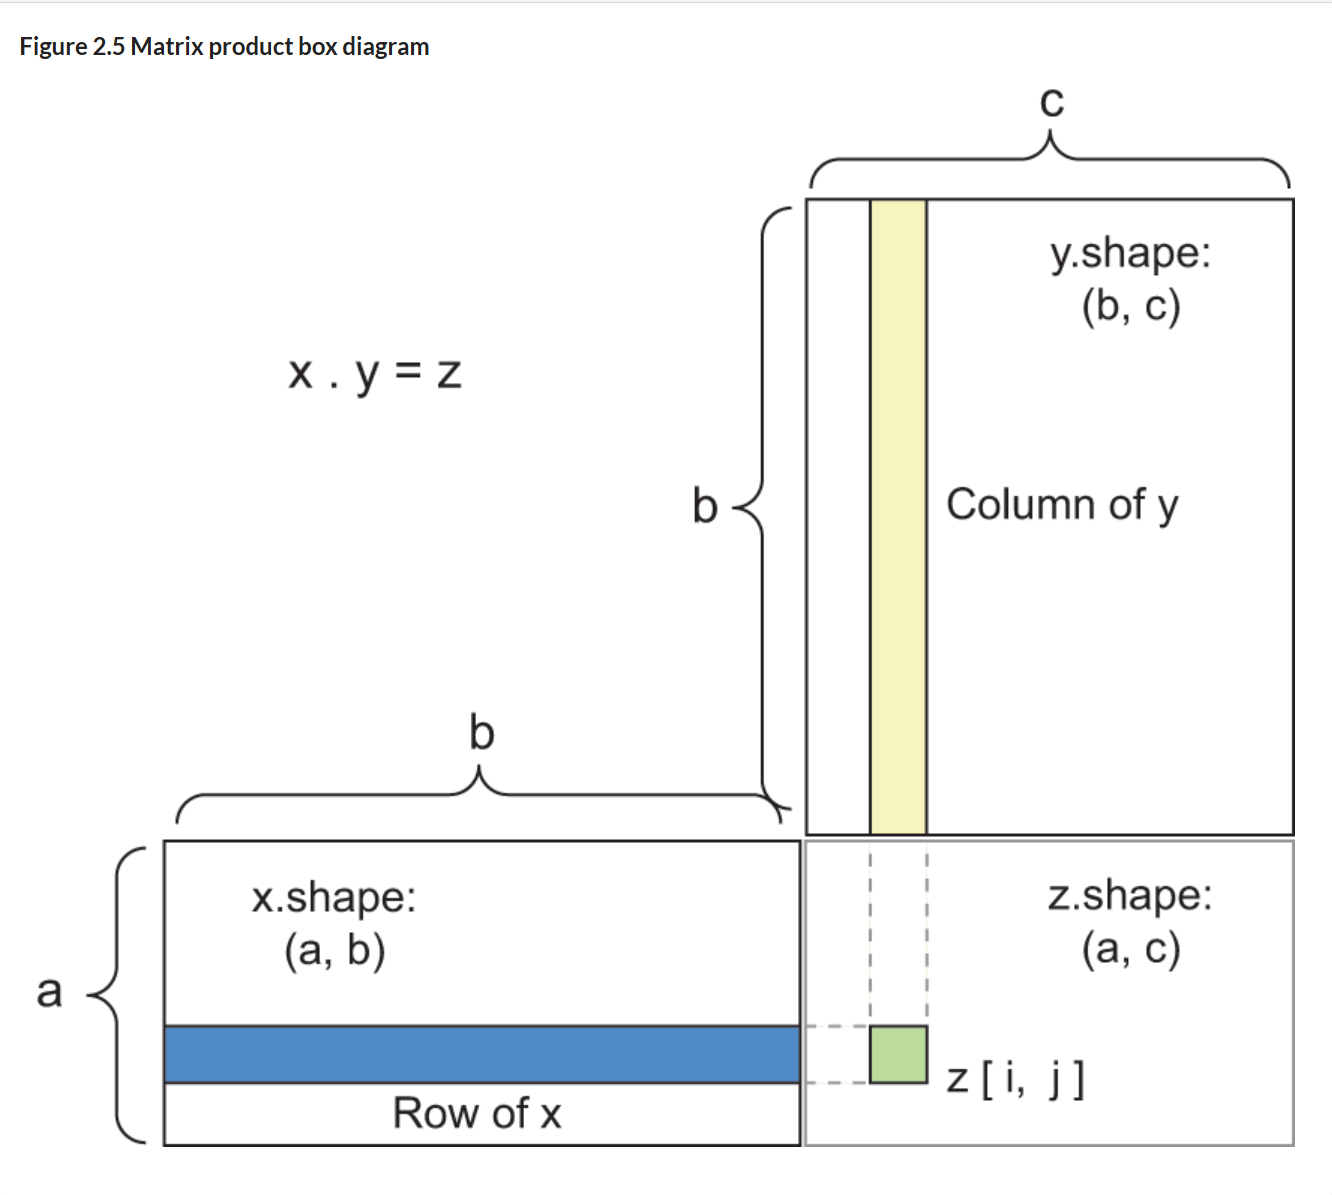

x, y, and z are pictured as rectangles (literal boxes of coefficients). Because the rows of x and the columns of y must have the same size, it follows that the width of x must match the height of y. If you go on to develop new machine-learning algorithms, you’ll likely be drawing such diagrams often.

More generally, you can take the product between higher-dimensional tensors, following the same rules for shape compatibility as outlined earlier for the 2D case:

#### Tensor reshaping

A third type of tensor operation that’s essential to understand is tensor reshaping. Although it wasn’t used in the Dense layers in our first neural network example, we used it when we preprocessed the digits data before feeding it into our model:

In [69]:
train_images = train_images.reshape((60000, 28 * 28))

Reshaping a tensor means rearranging its rows and columns to match a target shape. Naturally, the reshaped tensor has the same total number of coefficients as the initial tensor. Reshaping is best understood via simple examples:

In [70]:
x = np.array([[0., 1.],
              [2., 3.],
              [4., 5.]])
x.shape

(3, 2)

In [71]:
x = x.reshape((6, 1))
x

array([[0.],
       [1.],
       [2.],
       [3.],
       [4.],
       [5.]])

In [72]:
x = x.reshape((2, 3))
x

array([[0., 1., 2.],
       [3., 4., 5.]])

A special case of reshaping that’s commonly encountered is transposition. Transposing a matrix means exchanging its rows and its columns, so that x[i, :] becomes x[:, i]:

In [73]:
x = np.zeros((300, 20))
x = np.transpose(x)
x.shape

(20, 300)

#### Geometric interpretation of tensor operations

Because the contents of the tensors manipulated by tensor operations can be interpreted as coordinates of points in some geometric space, all tensor operations have a geometric interpretation. For instance, let’s consider addition. We’ll start with the following vector:

A = [0.5, 1]

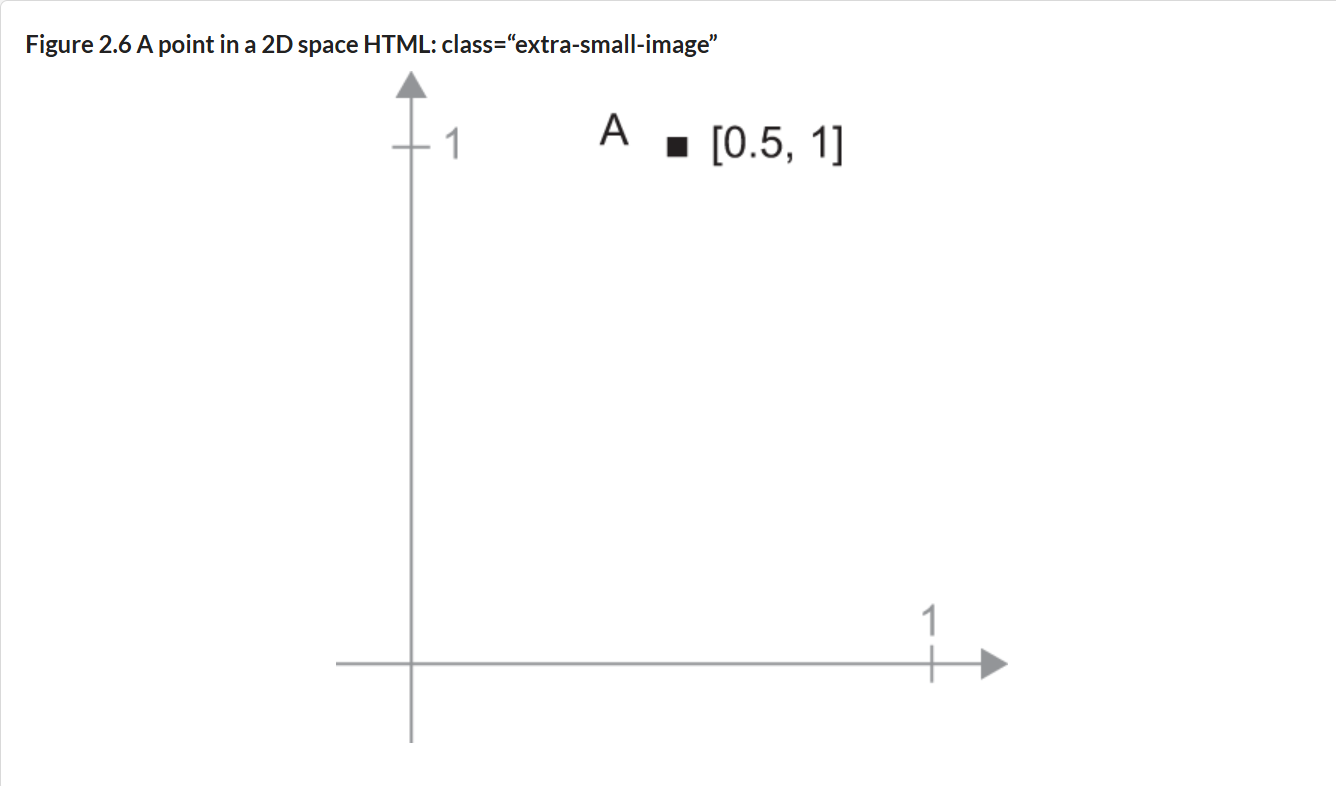

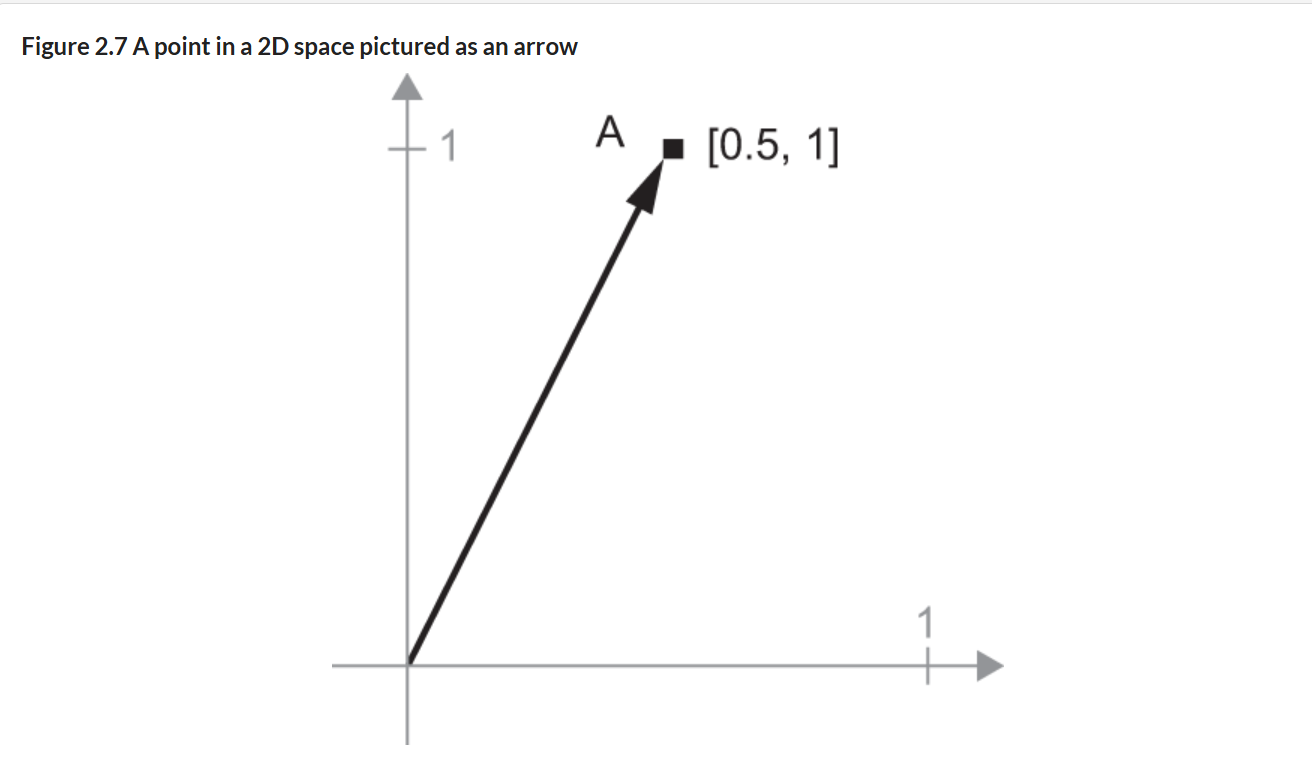

Let’s consider a new point, B = [1, 0.25], which we’ll add to the previous one. This is done geometrically by chaining together the vector arrows, with the resulting location being the vector representing the sum of the previous two vectors (see Figure 2.8). As you can see, adding a vector B to a vector A represents the action of copying point A in new location, whose distance and direction from the original point A is determine by the vector B. If you apply the same vector addition to a group of points in the plane (an “object”), you would be creating a copy of the entire object in a new location (see Figure 2.9). Tensor addition thus represents the action of translating an object (moving the object without distorting it) by a certain amount in a certain direction.

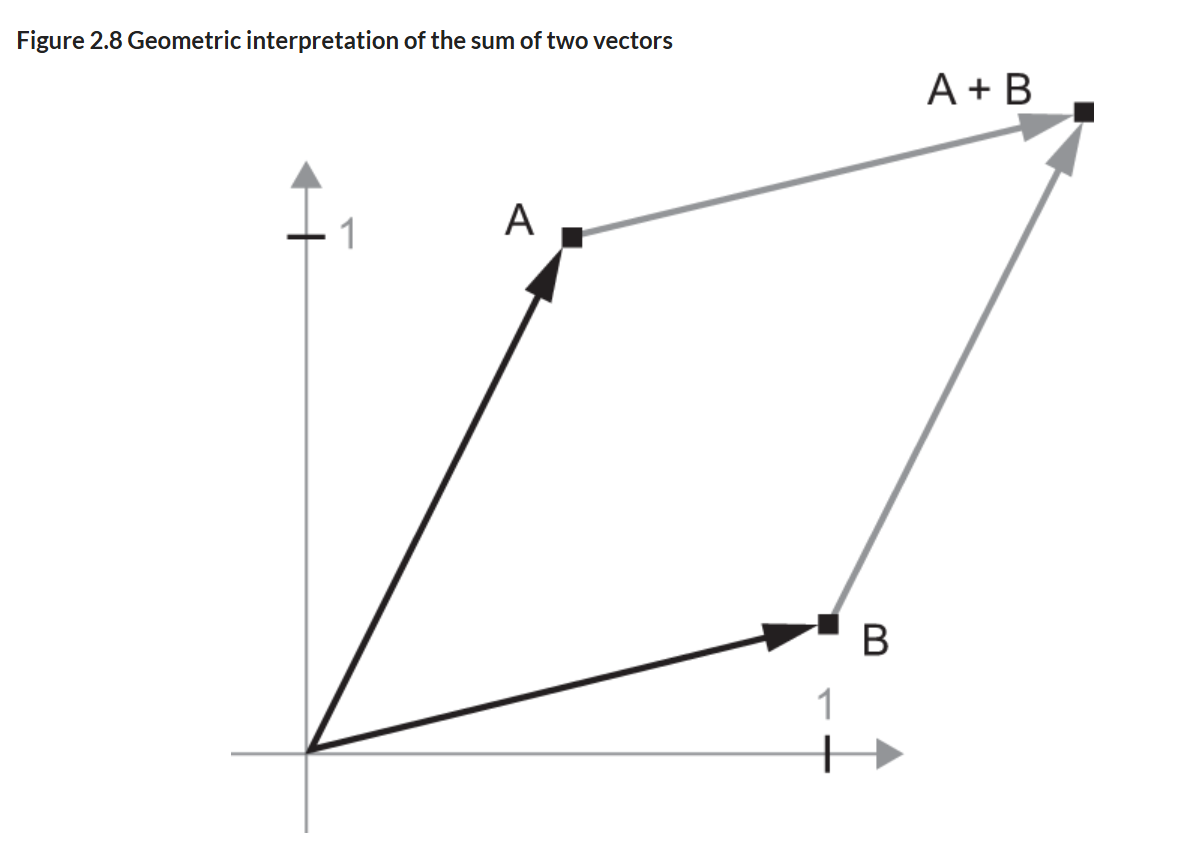

In general, elementary geometric operations such as translation, rotation, scaling, skewing, and so on can be expressed as tensor operations. Here are a few examples.

Translation: As you just saw, adding a vector to a point will move this point by a fixed amount in a fixed direction. Applied to a set of points (such as a 2D object), this is called a “translation” (see Figure 2.9).

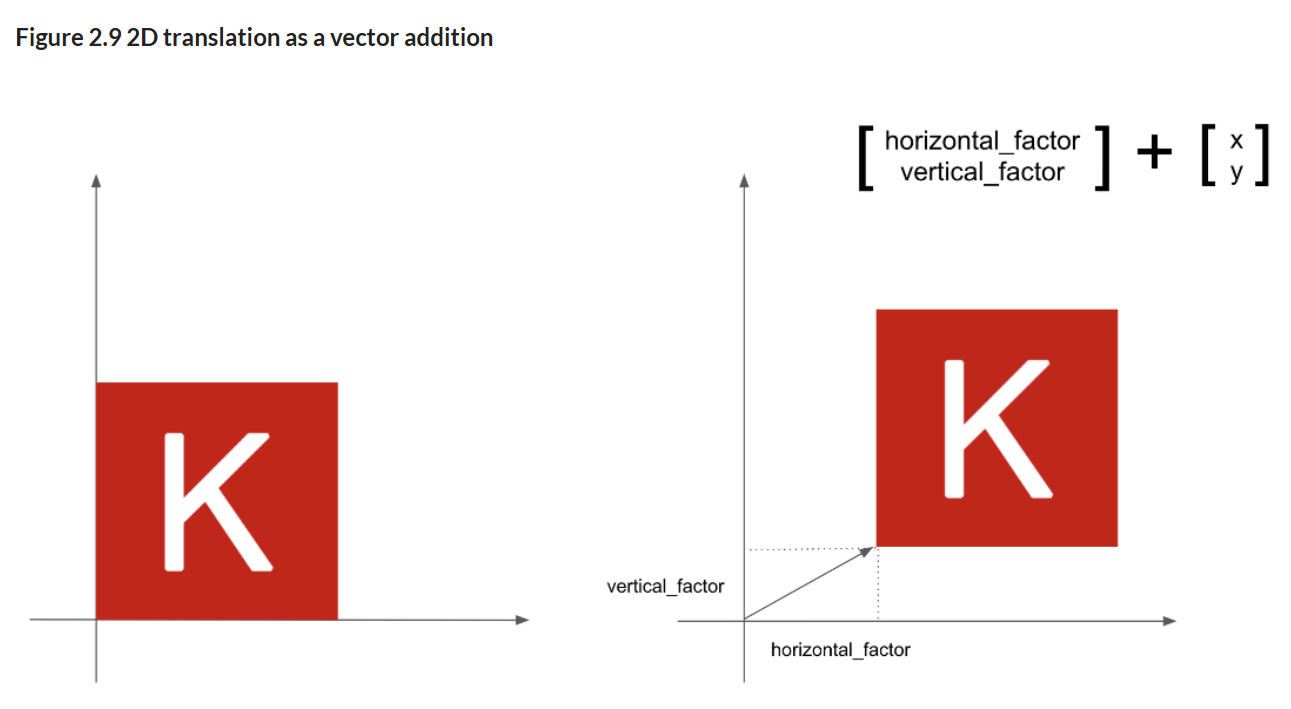

Rotation: A counterclockwise rotation of a 2D vector by an angle theta (see Figure 2.10) can be achieved via a product with a 2 × 2 matrix R = [[cos(theta), -sin(theta)], [sin(theta), cos(theta)]].

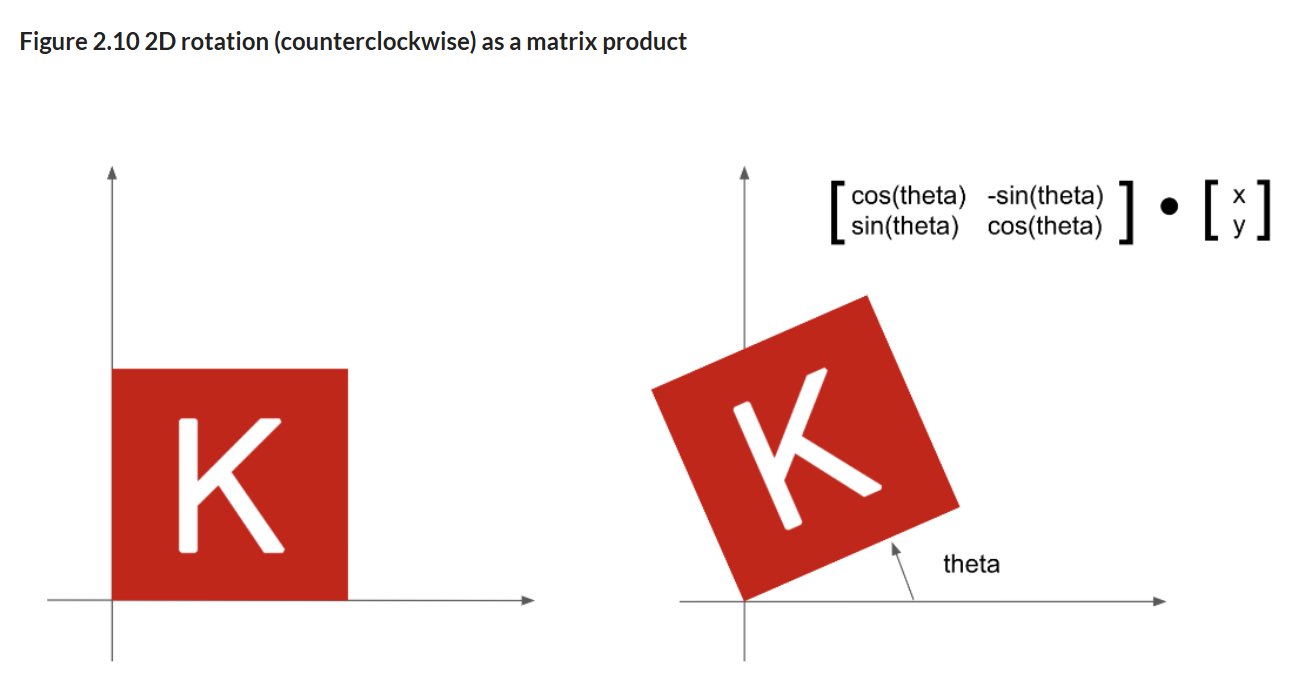

Scaling: A vertical and horizontal scaling of the image (see Figure 2.11) can be achieved via a product with a 2 x 2 matrix S = [[horizontal_factor, 0], [0, vertical_factor]] (note that such a matrix is called a “diagonal matrix”, because it only has non-zero coefficients in its “diagonal”, going from the top left to the bottom right).

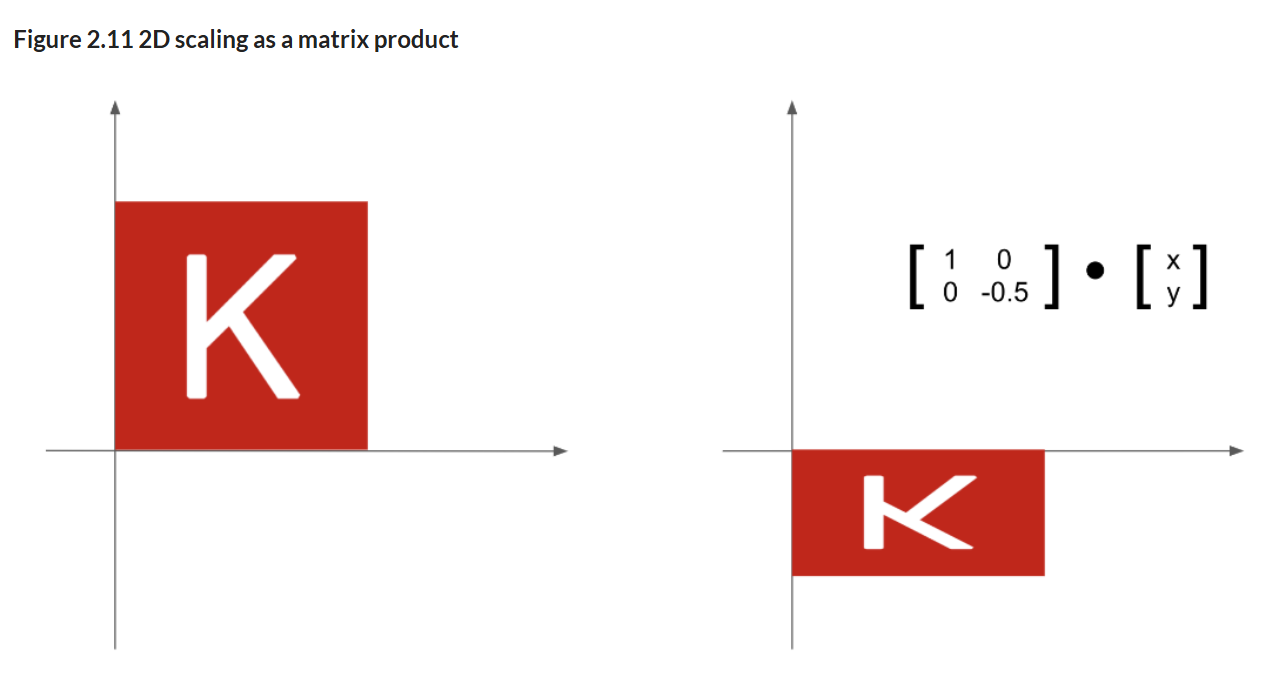

Linear transform: A product with an arbitrary matrix implements a linear transform. Note that scaling and rotation, seen above, are by definition linear transforms.

Affine transform: An affine transform (see Figure 2.12) is the combination of a linear transform (achieved via a matrix product) and a translation (achieved via a vector addition). As you have probably recognized, that’s exactly the y = W @ x + b computation implemented by the Dense layer! A Dense layer without an activation function is an affine layer.

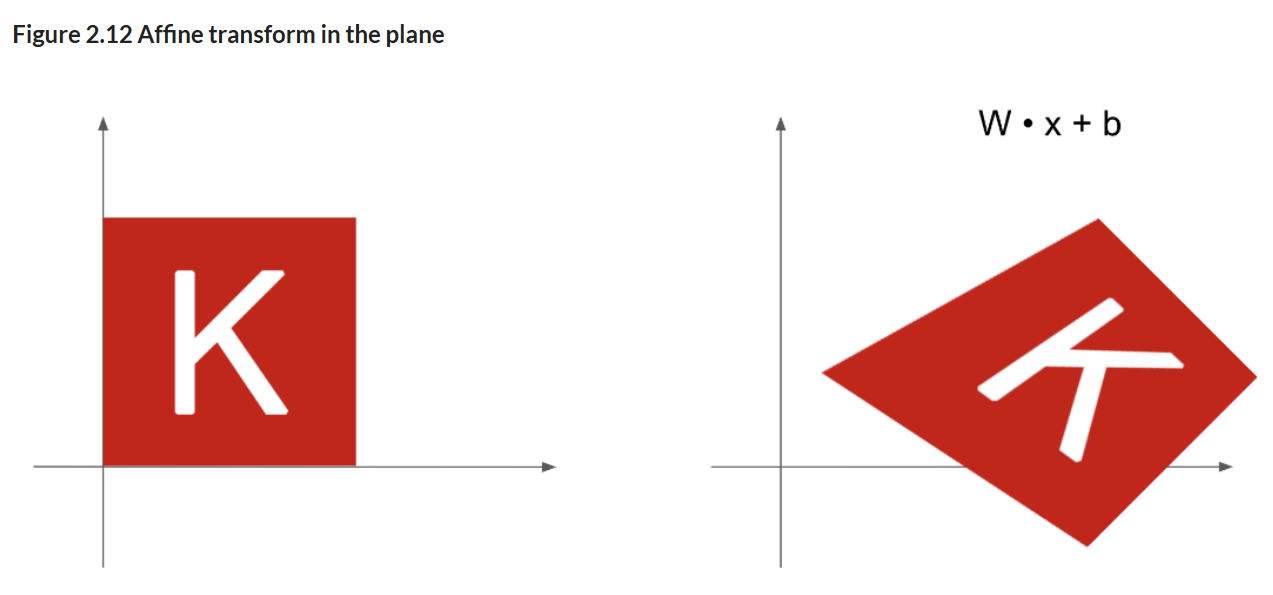

`Dense` layer with relu activation: An important observation about affine transforms is that if you apply many of them repeatedly, you still end up with an affine transform (so you could just have applied that one affine transform in the first place). Let’s try it with two: affine2(affine1(x)) = W2 @ (W1 @ x + b1) + b2 = (W2 @ W1) @ x + (W2 @ b1 + b2). That’s an affine transform where the linear part is the matrix W2 @ W1 and the translation part is the vector W2 @ b1 + b2. As a consequence, a multi-layer neural network made entirely of Dense layers without activations would be equivalent to a single Dense layer. This “deep” neural network would just be a linear model in disguise! This is why we need activation functions, like relu (seen in action in Figure 2.13). Thanks to activation functions, a chain of Dense layers can be made to implement very complex, non-linear geometric transformation, resulting in very rich hypothesis spaces for your deep neural networks. We cover this idea in more detail in the next chapter.

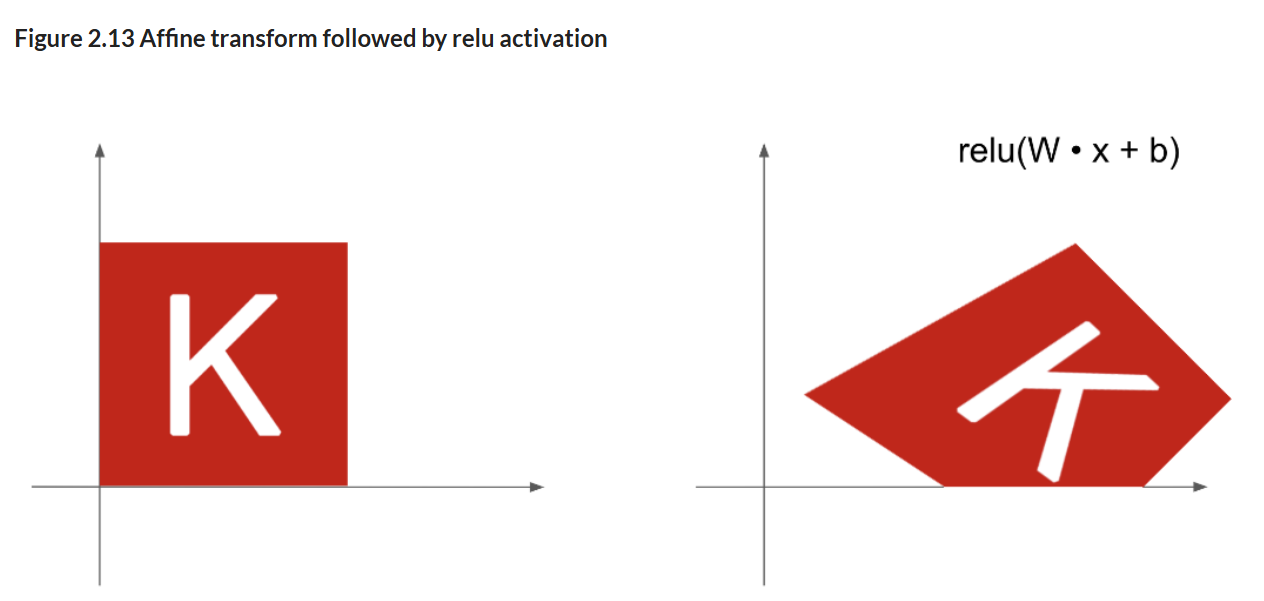

#### A geometric interpretation of deep learning



You just learned that neural networks consist entirely of chains of tensor operations, and that all of these tensor operations are just simple geometric transformations of the input data. It follows that you can interpret a neural network as a very complex geometric transformation in a high-dimensional space, implemented via a series of simple steps.

In 3D, the following mental image may prove useful. Imagine two sheets of colored paper: one red and one blue. Put one on top of the other. Now crumple them together into a small ball. That crumpled paper ball is your input data, and each sheet of paper is a class of data in a classification problem. What a neural network is meant to do is figure out a transformation of the paper ball that would uncrumple it, so as to make the two classes cleanly separable again. With deep learning, this would be implemented as a series of simple transformations of the 3D space, such as those you could apply on the paper ball with your fingers, one movement at a time.

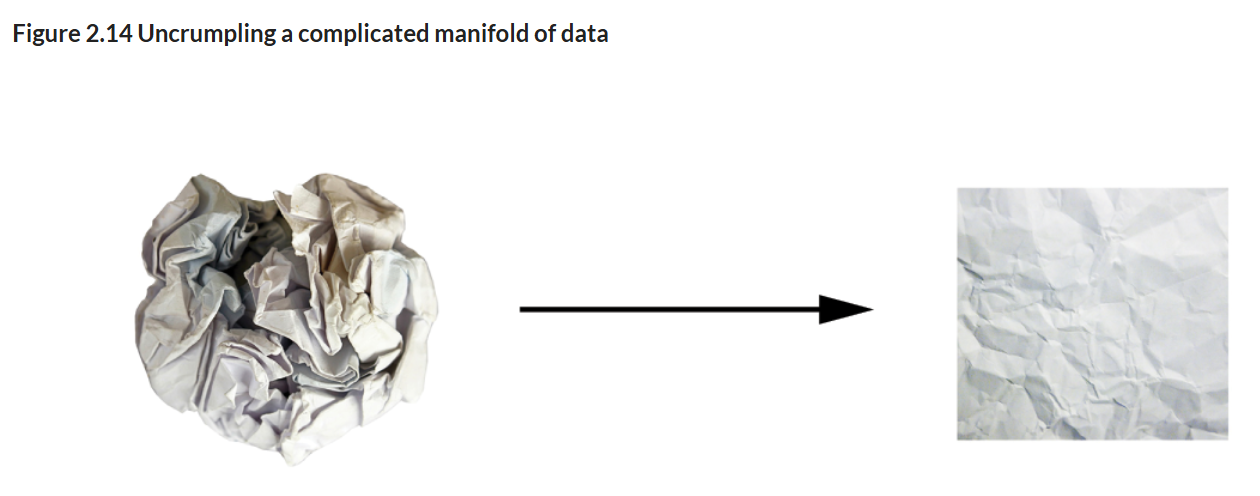

Uncrumpling paper balls is what machine learning is about: finding neat representations for
complex, highly-folded data manifolds in high-dimensional spaces (a manifold is a
continuous surface, like our crumpled sheet of paper). At this point, you should have a
pretty good intuition as to why deep learning excels at this: it takes the approach of
incrementally decomposing a complicated geometric transformation into a long chain of
elementary ones, which is pretty much the strategy a human would follow to uncrumple a
paper ball. Each layer in a deep network applies a transformation that disentangles the data
a little – and a deep stack of layers makes tractable an extremely complicated
disentanglement process.

### The engine of neural networks: gradient-based optimization

https://www.youtube.com/playlist?list=PLZHQObOWTQDNU6R1_67000Dx_ZCJB-3pi

As you saw in the previous section, each neural layer from our first model example
transforms its input data as follows:

output = relu(matmul(input, W) + b)

In this expression, W and b are tensors that are attributes of the layer. They’re called the
weights or trainable parameters of the layer (the kernel and bias attributes, respectively).
These weights contain the information learned by the model from exposure to training data.

Initially, these weight matrices are filled with small random values (a step called random
initialization). Of course, there’s no reason to expect that relu(matmul(input, W) + b),
when W and b are random, will yield any useful representations. The resulting
representations are meaningless – but they’re a starting point. What comes next is to
gradually adjust these weights, based on a feedback signal. This gradual adjustment, also
called training, is basically the learning that machine learning is all about.
This happens within what’s called a training loop, which works as follows. Repeat these
steps in a loop, until the loss seems sufficiently low:
1. Draw a batch of training samples x and corresponding targets y_true.
2. Run the model on x (a step called the forward pass) to obtain predictions
y_pred.
3. Compute the loss of the model on the batch, a measure of the mismatch
between y_pred and y_true.
4. Update all weights of the model in a way that slightly reduces the loss on
this batch.
You’ll eventually end up with a model that has a very low loss on its training data: a low
mismatch between predictions y_pred and expected targets y_true. The model has
“learned” to map its inputs to correct targets. From afar, it may look like magic, but when
you reduce it to elementary steps, it turns out to be simple.
Step 1 sounds easy enough – it’s just I/O code. Steps 2 and 3 are merely the application
of a handful of tensor operations, so you could implement these steps purely from what you
learned in the previous section. The difficult part is step 4: updating the model’s weights.
Given an individual weight coefficient in the model, how can you compute whether the
coefficient should be increased or decreased, and by how much?
One naive solution would be to freeze all weights in the model except the one scalar
coefficient being considered, and try different values for this coefficient. Let’s say the initial
value of the coefficient is 0.3. After the forward pass on a batch of data, the loss of the
model on the batch is 0.5. If you change the coefficient’s value to 0.35 and rerun the
forward pass, the loss increases to 0.6. But if you lower the coefficient to 0.25, the loss falls
to 0.4. In this case, it seems that updating the coefficient by -0.05 would contribute to
minimizing the loss. This would have to be repeated for all coefficients in the model.
But such an approach would be horribly inefficient, because you’d need to compute two
forward passes (which are expensive) for every individual coefficient (of which there are
many, usually at least a few thousands and potentially up to billions). Thankfully, there’s a
much better approach: gradient descent.

Gradient descent is the optimization technique that powers modern neural networks.
Here’s the gist of it. All of the functions used in our models (such as matmul or +) transform
their input in a smooth and continuous way: if you look at z = x + y, for instance, a small
change in y only results in a small change in z, and if you know the direction of the change
in y, you can infer the direction of the change in z. Mathematically, you’d say these
functions are differentiable. If you chain together such functions, the bigger function you
obtain is still differentiable. In particular, this applies to the function that maps the model’s
coefficients to the loss of the model on a batch of data: a small change of the model’s
coefficients results in a small, predictable change of the loss value. This enables you to use
a mathematical operator called the gradient to describe how the loss varies as you move
the model’s coefficients in different directions. If you compute this gradient, you can use it
to move the coefficients (all at once in a single update, rather than one at a time) in a
direction that decreases the loss.
If you already know what differentiable means and what a gradient is, you can skip the
next two sections. Otherwise, the following will help you understand these concepts.

#### What's a derivative?

For every differentiable function f(x) (differentiable means “can be derived”: for example,
smooth, continuous functions can be derived), there exists a derivative function f'(x) that
maps values of x to the slope of the local linear approximation of f in those points. For
instance, the derivative of cos(x) is -sin(x), the derivative of f(x) = a * x is f'(x) = a,
and so on.
Being able to derive functions is a very powerful tool when it comes to optimization, the
task of finding values of x that minimize the value of f(x). If you’re trying to update x by a
factor epsilon_x in order to minimize f(x), and you know the derivative of f, then your
job is done: the derivative completely describes how f(x) evolves as you change x. If you
want to reduce the value of f(x), you just need to move x a little in the opposite direction
from the derivative.

#### Derivative of a tensor operation: the gradient

The function we were just looking at turned a scalar value x into another scalar value y:
you could plot it as a curve in a 2D plane. Now, imagine a function that turns a tuple of
scalars (x, y) into a scalar value z: that would be a vector operation. You could plot it as a
2D surface in a 3D space (indexed by coordinates x, y, z). Likewise, you can imagine
functions that take as input matrices, functions that take as input rank-3 tensors, etc.

The concept of derivation can be applied to any such function, as long as the surfaces
they describe are continuous and smooth. The derivative of a tensor operation (or tensor
function) is called a gradient. Gradients are just the generalization of the concept of
derivatives to functions that take tensors as inputs. Remember how, for a scalar function,
the derivative represents the local slope of the curve of the function? In just the same way,
the gradient of a tensor function represents the curvature of the multidimensional surface
described by the function. It characterizes how the output of the function varies when its
input parameters vary.

Let’s look at an example grounded in machine learning. Consider:

An input vector x (a sample in a dataset)

A matrix W (the weights of a model)

A target y_true (what the model should learn to associated to x)

A loss function loss (meant to measure the gap between the model’s
current predictions and y_true).

You can use W to compute a target candidate y_pred, and then compute the loss, or
mismatch, between the target candidate y_pred and the target y_true:

y_pred = matmul(x, W) #1

loss_value = loss(y_pred, y_true) #2

#1 We use the model weights W to make a prediction for x.

#2 We estimate how far off the prediction was.

Now, we’d like to use gradients to figure out how to update W so as to make loss_value
smaller. How do we do that?
Given fixed inputs x and y_true, the operations above can be interpreted as a function
mapping values of W (the model’s weights) to loss values:

Let’s say the current value of W is W0. Then the derivative of f in the point W0 is a tensor
grad(loss_value, W0), with the same shape as W, where each coefficient
grad(loss_value, W0)[i, j] indicates the direction and magnitude of the change in
loss_value you observe when modifying W0[i, j]. That tensor grad(loss_value, W0) is
the gradient of the function f(W) = loss_value in W0, also called “gradient of
+loss_value+ with respect to W around W0”.

Concretely, what does grad(loss_value, W0) represent? You saw earlier that the
derivative of a function f(x) of a single coefficient can be interpreted as the slope of the
curve of f. Likewise, grad(loss_value, W0) can be interpreted as the tensor describing
the curvature of loss_value = f(W) around W0. Each partial derivative describes the
curvature of f in a specific direction.

We just saw how for a function f(x), you can reduce the value of f(x) by moving x a
little in the opposite direction from the derivative. In much the same way, with a function
f(W) of a tensor, you can reduce loss_value = f(W) by moving W in the opposite direction
from the gradient, such as an update of W1 = W0 - step * grad(f(W0), W0) where step
is a small scaling factor. That means going against the curvature, which intuitively should
put you lower on the curve. Note that the scaling factor step is needed because
grad(loss_value, W0) only approximates the curvature when you’re close to W0, so you
don’t want to get too far from W0.

#### Stochastic gradient descent

Given a differentiable function, it’s theoretically possible to find its minimum analytically:
it’s known that a function’s minimum is a point where the derivative is 0, so all you have to
do is find all the points where the derivative goes to 0 and check for which of these points
the function has the lowest value.
Applied to a neural network, that means finding analytically the combination of weight
values that yields the smallest possible loss function. This can be done by solving the
equation grad(f(W), W) = 0 for W. This is a polynomial equation of N variables, where N is
the number of coefficients in the model. Although it would be possible to solve such an
equation for N = 2 or N = 3, doing so is intractable for real neural networks, where the
number of parameters is never less than a few thousand and can sometimes be in the
billions.
Instead, you can use the four-step algorithm outlined at the beginning of this section:
modify the parameters little by little based on the current loss value on a random batch of
data. Because you’re dealing with a differentiable function, you can compute its gradient,
which gives you an efficient way to implement step 4. If you update the weights in the
opposite direction from the gradient, the loss will be a little less every time:
1. Draw a batch of training samples x and corresponding targets y_true.
2. Run the model on x to obtain predictions y_pred (this is called the
forward pass).
3. Compute the loss of the model on the batch, a measure of the mismatch
between y_pred and y_true.
4. Compute the gradient of the loss with regard to the model’s parameters
(this is called the backward pass).
5. Move the parameters a little in the opposite direction from the gradient –
for example W -= learning_rate * gradient – thus reducing the loss
on the batch a bit. The learning rate (learning_rate here) would be a
scalar factor modulating the “speed” of the gradient descent process.

Easy enough! What we just described is called mini-batch stochastic gradient descent
(mini-batch SGD). The term stochastic refers to the fact that each batch of data is drawn at
random (stochastic is a scientific synonym of random). Figure 2.18 illustrates what happens
in 1D, when the model has only one parameter and you have only one training sample.

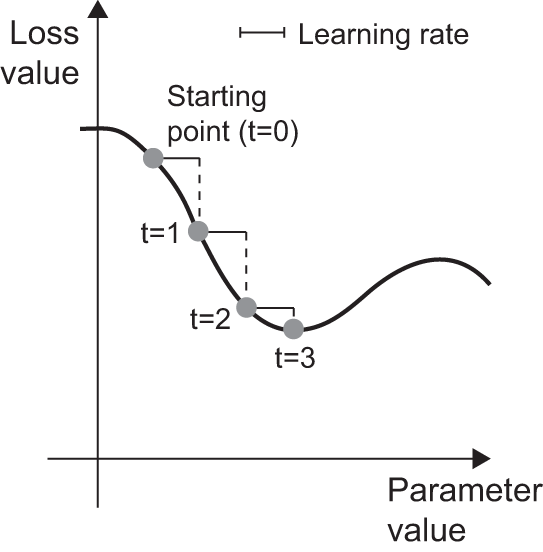


We can see intuitively that it’s important to pick a reasonable value for the learning_rate
factor. If it’s too small, the descent down the curve will take many iterations, and it could
get stuck in a local minimum. If learning_rate is too large, your updates may end up
taking you to completely random locations on the curve.
Note that a variant of the mini-batch SGD algorithm would be to draw a single sample
and target at each iteration, rather than drawing a batch of data. This would be true SGD
(as opposed to mini-batch SGD). Alternatively, going to the opposite extreme, you could
run every step on all data available, which is called batch gradient descent. Each update
would then be more accurate, but far more expensive. The efficient compromise between
these two extremes is to use mini-batches of reasonable size.

Although Figure 2.18 illustrates gradient descent in a 1D parameter space, in practice
you’ll use gradient descent in highly dimensional spaces: every weight coefficient in a
neural network is a free dimension in the space, and there may be tens of thousands or
even millions of them. To help you build intuition about loss surfaces, you can also visualize
gradient descent along a 2D loss surface, as shown in Figure 2.19. But you can’t possibly
visualize what the actual process of training a neural network looks like – you can’t
represent a 1,000,000-dimensional space in a way that makes sense to humans. As such,
it’s good to keep in mind that the intuitions you develop through these low-dimensional
representations may not always be accurate in practice. This has historically been a source
of issues in the world of deep-learning research.

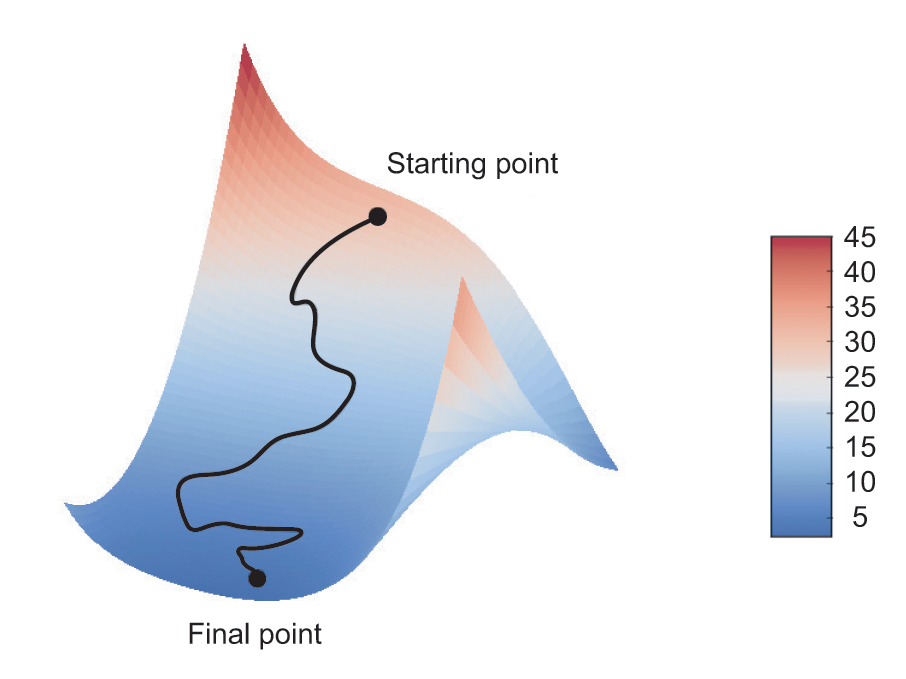

Additionally, there exist multiple variants of SGD that differ by taking into account previous
weight updates when computing the next weight update, rather than just looking at the
current value of the gradients. There is, for instance, SGD with momentum, as well as
Adagrad, RMSprop, and several others. Such variants are known as optimization methods
or optimizers. In particular, the concept of momentum, which is used in many of these
variants, deserves your attention. Momentum addresses two issues with SGD: convergence
speed and local minima. Consider Figure 2.20, which shows the curve of a loss as a
function of a model parameter.

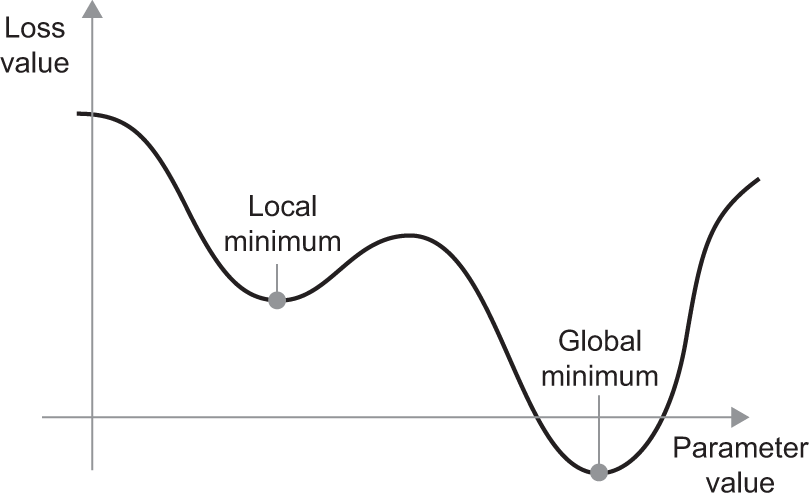

As you can see, around a certain parameter value, there is a local minimum: around that
point, moving left would result in the loss increasing, but so would moving right. If the
parameter under consideration were being optimized via SGD with a small learning rate,
then the optimization process would get stuck at the local minimum instead of making its
way to the global minimum.
You can avoid such issues by using momentum, which draws inspiration from physics. A
useful mental image here is to think of the optimization process as a small ball rolling down
the loss curve. If it has enough momentum, the ball won’t get stuck in a ravine and will end
up at the global minimum. Momentum is implemented by moving the ball at each step
based not only on the current slope value (current acceleration) but also on the current
velocity (resulting from past acceleration). In practice, this means updating the parameter
w based not only on the current gradient value but also on the previous parameter update,
such as in this naive implementation:

past_velocity = 0.0

momentum = 0.1 #1

while loss > 0.01: #2

    w, loss, gradient = get_current_parameters()
    
    velocity = past_velocity * momentum - learning_rate * gradient
    
    w = w + momentum * velocity - learning_rate * gradient
    
    past_velocity = velocity
    
    update_parameter(w)

#### Chaining derivatives: the Backpropagation algorithm

In the algorithm above, we casually assumed that because a function is differentiable, we
can easily compute its gradient. But is that true? How can we compute the gradient of
complex expressions in practice? In our two-layer network example, how can we get the
gradient of the loss with regard to the weights? That’s where the backpropagation algorithm
comes in.

##### The chain rule

Backpropagation is a way to use the derivative of simple operations (such as addition, relu,
or tensor product) to easily compute the gradient of arbitrarily complex combinations of
these atomic operations. Crucially, a neural network consists of many tensor operations
chained together, each of which has a simple, known derivative. For instance, the model
from our first example can be expressed as a function parameterized by the variables W1,
b1, W2, and b2 (belonging to the first and second Dense layers respectively), involving the
atomic operations matmul, relu, softmax, and +, as well as our loss function loss, which
are all easily differentiable:

loss_value = loss(
y_true,
softmax(matmul(relu(matmul(inputs, W1) + b1), W2) + b2),
)

Calculus tells us that such a chain of functions can be derived using the following identity,
called the chain rule:

Consider two functions f and g, as well as the composed function fg such that y =
fg(x) == f(g(x)):

def fg(x):

    x1 = g(x)

    y = f(x1)

    return y

Then the chain rule states that grad(y, x) == grad(y, x1) * grad(x1, x). This enables
you to compute the derivative of fg as long as you know the derivatives of f and g. The
chain rule is named like this because when you add more intermediate functions, it starts
looking like a chain:

def fghj(x):

    x1 = j(x)

    x2 = h(x1)

    x3 = g(x2)

    y = f(x3)

    return y

grad(y, x) == grad(y, x3) * grad(x3, x2) * grad(x2, x1) * grad(x1, x)

Applying the chain rule to the computation of the gradient values of a neural network gives
rise to an algorithm called backpropagation. Let’s see how that works, concretely.

##### Automatic differentiation with computation graphs

useful way to think about backpropagation is in terms of computation graphs. A
computation graph is the data structure at the heart of the deep learning revolution. It’s a
directed acyclic graph of operations – in our case, tensor operations. For instance, this is
the graph representation of our first model:

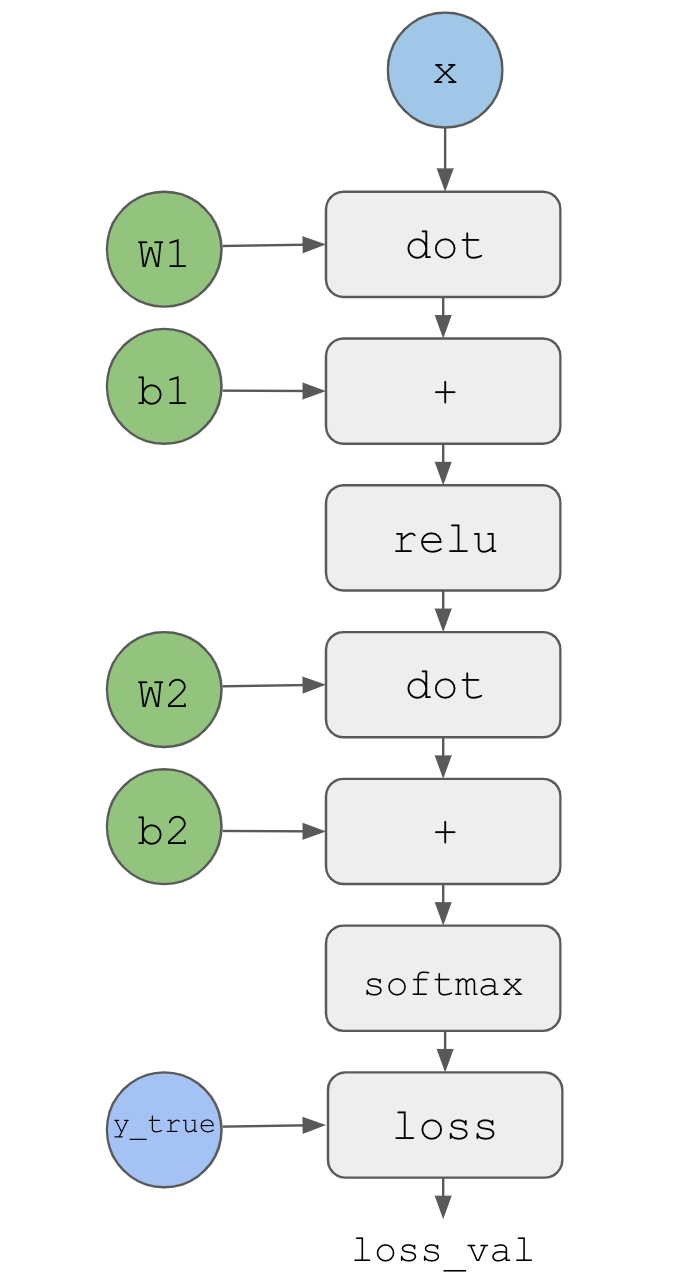

Computation graphs have been an extremely successful abstraction in computer science
because they enable us to treat computation as data: a computable expression is encoded
as a machine-readable data structure that can be used as the input or output of another
program. For instance, you could imagine a program that receives a computation graph and
returns a new computation graph that implements a large-scale distributed version of the
same computation – this would mean that you could distribute any computation without
having to write the distribution logic yourself. Or imagine… a program that receives a
computation graph and can automatically generate the derivative of the expression it
represents. It’s much easier to do these things if your computation is expressed as an
explicit graph data structure rather than, say, lines of ASCII characters in a .py file.

To explain backpropagation clearly, let’s look at a really basic example of a computation
graph. We’ll consider a simplified version of the graph above, where we only have one
linear layer and where all variables are scalar. We’ll take two scalar variables w, b, a scalar
input x, and apply some operations to them to combine into an output y. Finally, we’ll apply
an absolute value error loss function: loss_val = abs(y_true - y). Since we want to
update w and b in a way that would minimize loss_val, we are interested in computing
grad(loss_val, b) and grad(loss_val, w).

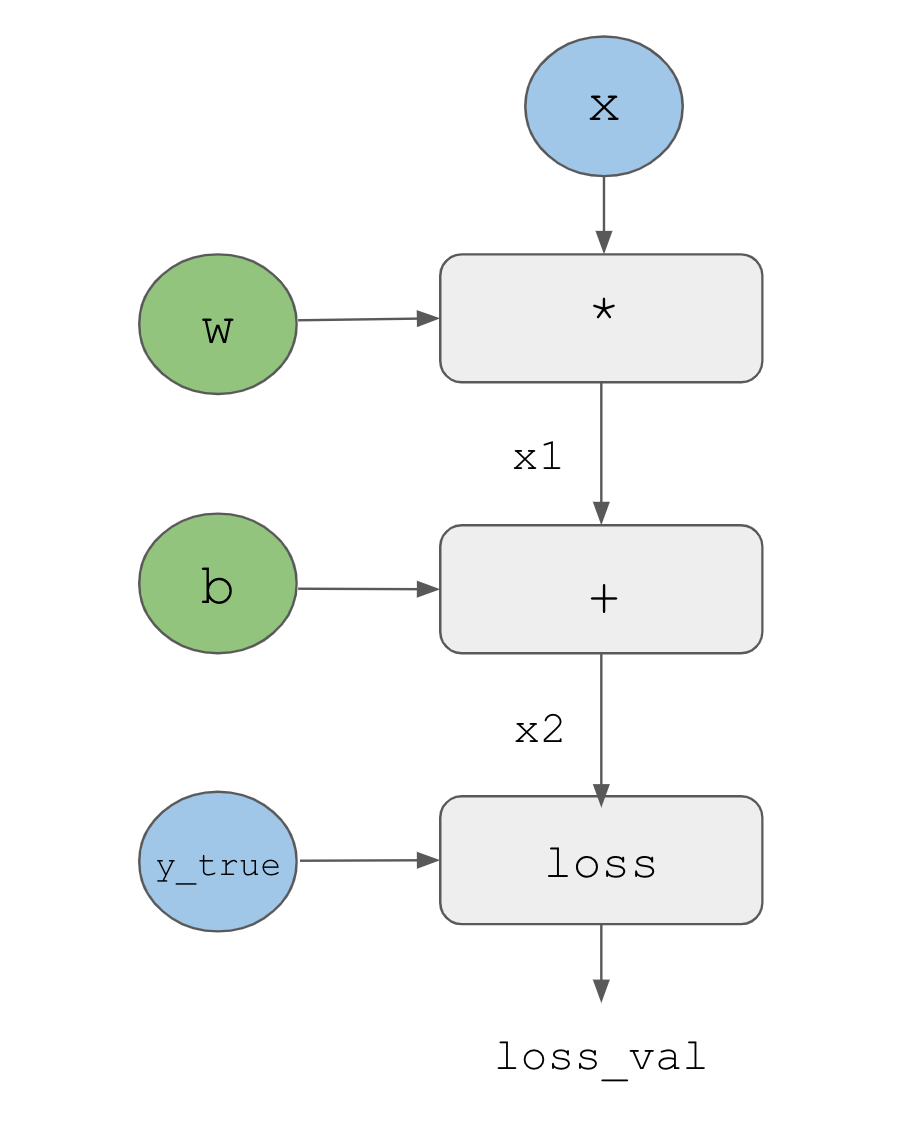

Let’s set concrete values for the “input nodes” in the graph, that is to say the input x, the
target y_true, w and b. We propagate these values to all nodes in the graph, from top to
bottom, until we reach loss_val. This is the forward pass.

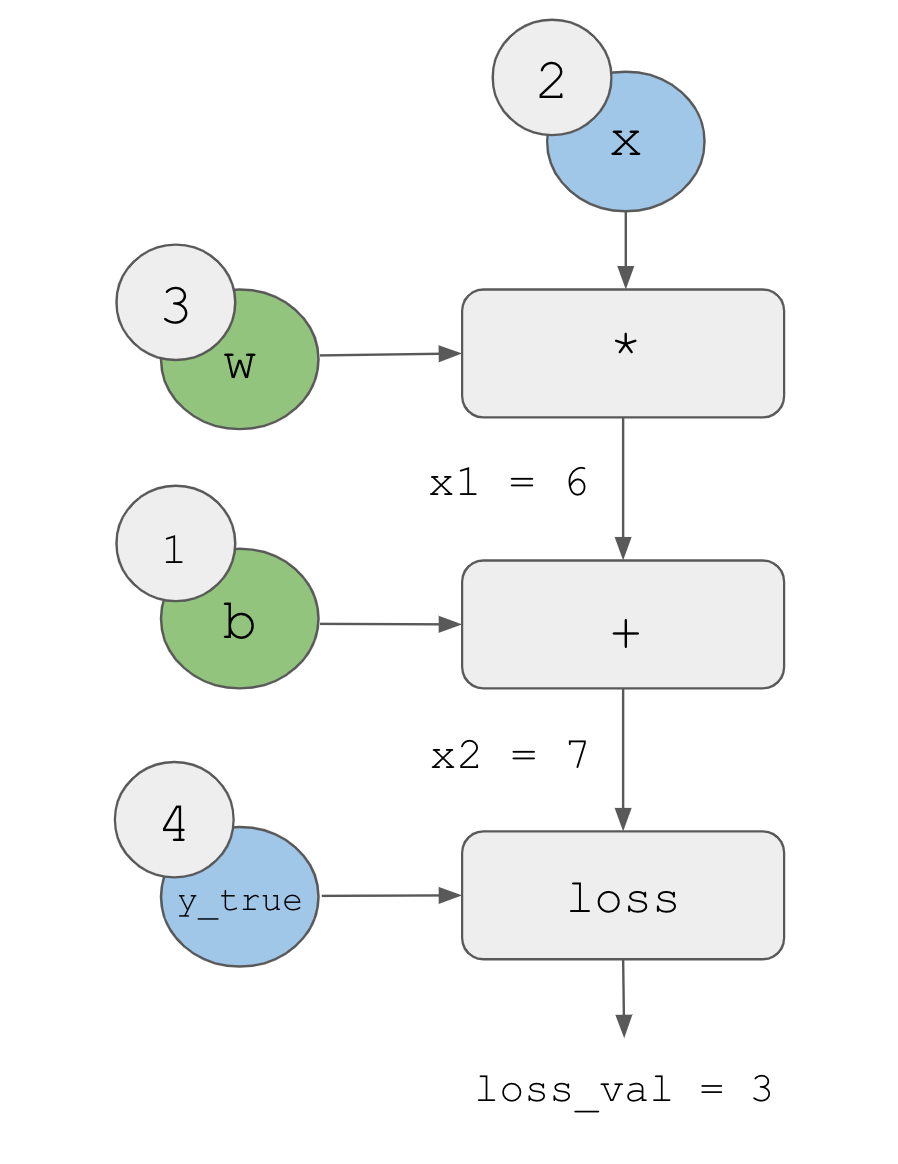

Now let’s “reverse” the graph: for each edge in the graph going from A to B, we will create
an opposite edge from B to A, and ask "`how much does +B+ vary when A varies?" That
is to say, what is `+grad(B, A)+? We’ll annotate each inverted edge with this value.
This backward graph represents the backward pass.

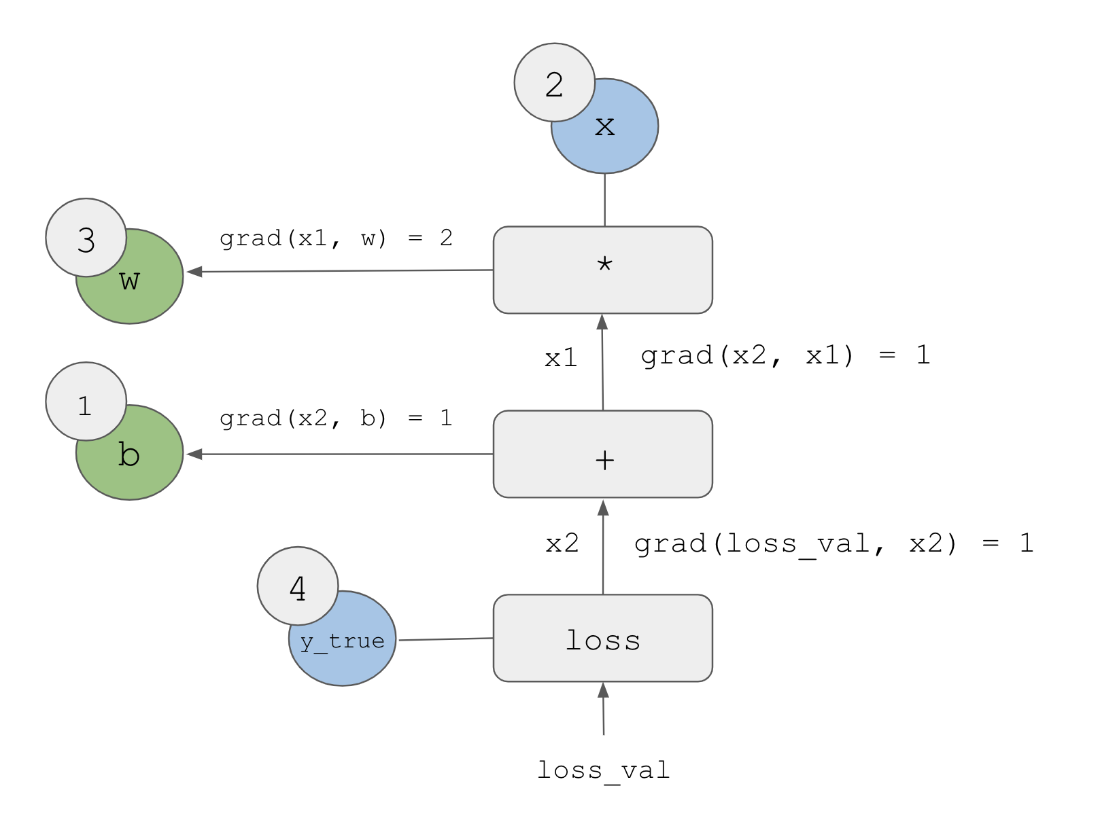

We have:
grad(loss_val, x2) = 1, because as x2 varies by an amount epsilon,

loss_val = abs(4 - x2) varies by the same amount.

grad(x2, x1) = 1, because as x1 varies by an amount epsilon, x2 = x1 + b = x1 + 1 varies by the same amount.

grad(x2, b) = 1, because as b varies by an amount epsilon, x2 = x1 + b = 6 + b varies by the same amount.

grad(x1, w) = 2, because as w varies by an amount epsilon, x1 = x * w = 2 * w varies by 2 * epsilon.

What the chain rule says about this backward graph is that you can obtain the derivative of
a node with respect to another node by multiplying the derivatives for each edge along the
path linking the two nodes. For instance, grad(loss_val, w) = grad(loss_val, x2) * grad(x2, x1) * grad(x1, w).

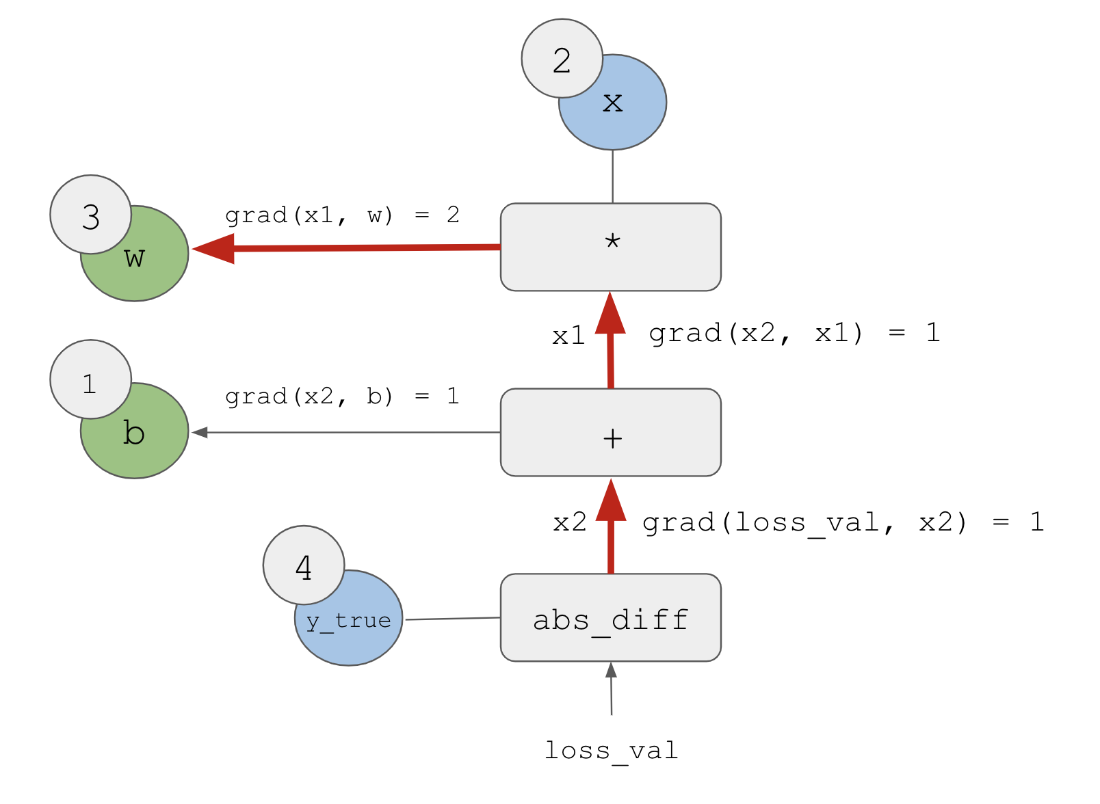

By applying the chain rule to our graph, we obtain what we were looking for:

grad(loss_val, w) = 1 * 1 * 2 = 2

grad(loss_val, b) = 1 * 1 = 1

And with that, you just saw backpropagation in action! Backpropagation is simply the
application of the chain rule to a computation graph. There’s nothing more to it.
Backpropagation starts with the final loss value and works backward from the top layers to
the bottom layers, computing the contribution that each parameter had in the loss value.
That’s where the name “backpropagation” comes from: we “back propagate” the loss
contributions of different nodes in a computation graph.

Nowadays, people implement neural networks in modern frameworks that are capable of
automatic differentiation, such as JAX, TensorFlow, or PyTorch. Automatic differentiation is
implemented with the kind of computation graph presented above. Automatic differentiation
makes it possible to retrieve the gradients of arbitrary compositions of differentiable tensor
operations without doing any extra work besides writing down the forward pass. When I
wrote my first neural networks in C in the 2000s, I had to write my gradients by hand.
Now, thanks to modern automatic differentiation tools, you’ll never have to implement
backpropagation yourself. Consider yourself lucky!

### Looking back at our first example

You’re nearing the end of this chapter, and you should now have a general understanding of
what’s going on behind the scenes in a neural network. What was a magical black box at
the start of the chapter has turned into a clearer picture, as illustrated in Figure 2.26: the
model, composed of layers that are chained together, maps the input data to predictions.
The loss function then compares these predictions to the targets, producing a loss value: a
measure of how well the model’s predictions match what was expected. The optimizer uses
this loss value to update the model’s weights.

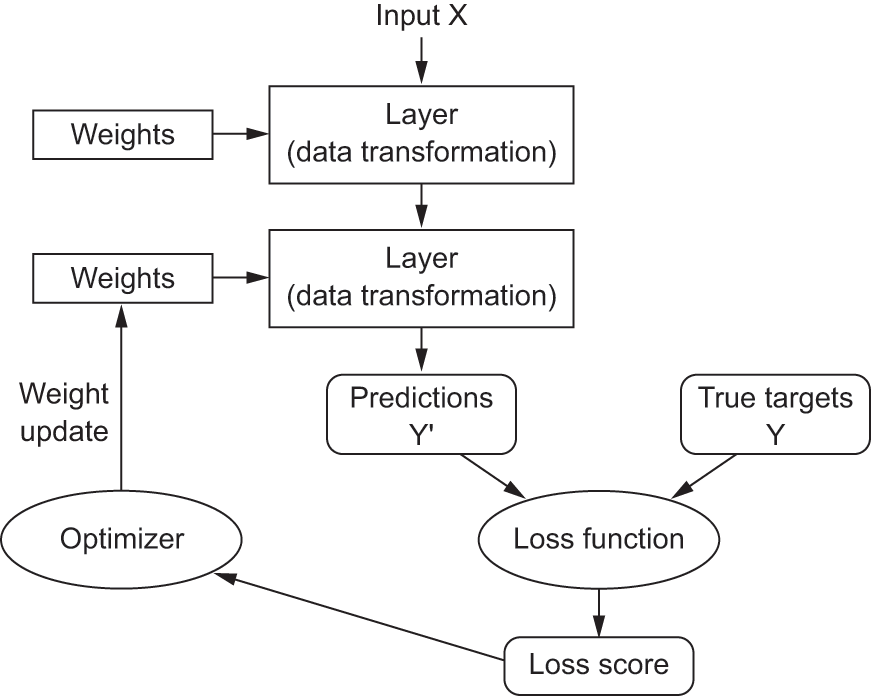

Let’s go back to the first example and review each piece of it in the light of what you’ve
learned in the previous sections.
This was the input data:

In [74]:
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255
test_images = test_images.reshape((10000, 28 * 28))
test_images = test_images.astype("float32") / 255

Now you understand that the input images are stored in NumPy tensors, which are here
formatted as float32 tensors of shape (60000, 784) (training data) and (10000, 784)
(test data), respectively.

This was our model:

In [75]:
model = keras.Sequential(
    [
        layers.Dense(512, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)

Now you understand that this model consists of a chain of two Dense layers, that each layer
applies a few simple tensor operations to the input data, and that these operations involve
weight tensors. Weight tensors, which are attributes of the layers, are where the knowledge
of the model persists.
This was the model-compilation step:

In [76]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

Now you understand that "sparse_categorical_crossentropy" is the loss function that’s
used as a feedback signal for learning the weight tensors, and which the training phase will
attempt to minimize. You also know that this reduction of the loss happens via mini-batch
stochastic gradient descent. The exact rules governing a specific use of gradient descent
are defined by the "adam" optimizer passed as the first argument.
Finally, this was the training loop:

In [77]:
model.fit(
    train_images,
    train_labels,
    epochs=5,
    batch_size=128,
)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.8697 - loss: 0.4592
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9655 - loss: 0.1205
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9796 - loss: 0.0712
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9863 - loss: 0.0494
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9889 - loss: 0.0373


Now you understand what happens when you call fit: the model will start to iterate on the
training data in mini-batches of 128 samples, 5 times over (each iteration over all the
training data is called an epoch). For each batch, the model will compute the gradient of the
loss with regard to the weights (using the backpropagation algorithm, which derives from
the chain rule in calculus), and move the weights in the direction that will reduce the value
of the loss for this batch.
After these 5 epochs, the model will have performed 2,345 gradient updates (469 per
epoch), and the loss of the model will be sufficiently low that the model will be capable of
classifying handwritten digits with high accuracy.
At this point, you already know most of what there is to know about neural networks.
Let’s prove it by reimplementing a simplified version of that first example step by step,
using only low-level operations.

#### Reimplementing our first example from scratch

What’s better to demonstrate full, unambiguous understanding than to implement
everything from scratch? Of course, what “from scratch” means here is relative: we won’t
reimplement basic tensor operations, and we won’t implement backpropagation. But we’ll
go to such a low level that each computation step will be made explicit.
Don’t worry if you don’t understand every little detail in this example just yet. The next
chapter will dive in more detail into the Keras API. For now, just try to follow the gist of
what’s going on – the intent of this example is to help crystalize your understanding of the
mathematics of deep learning using a concrete implementation. Let’s go!

##### A simple Dense class

You’ve learned earlier that the Dense layer implements the following input transformation,
where W and b are model parameters, and activation is an elementwise function (usually
relu):

In [78]:
keras.config.set_backend("tensorflow")

Let’s implement a simple Python class NaiveDense that creates two Keras variables W and
b, and exposes a __call__() method that applies the above transformation.

In [79]:
import keras
from keras import ops

class NaiveDense:
    def __init__(self, input_size, output_size, activation=None):
        self.activation = activation
        self.W = keras.Variable(
            shape=(input_size, output_size), initializer="uniform"
        )
        self.b = keras.Variable(shape=(output_size,), initializer="zeros")

    def __call__(self, inputs):
        x = ops.matmul(inputs, self.W)
        x = x + self.b
        if self.activation is not None:
            x = self.activation(x)
        return x

    @property
    def weights(self):
        return [self.W, self.b]

#1 keras.ops is where you will find all the tensor operations you need.

#2 Create a matrix W of shape “(input_size, output_size)”, initialized with random values drawn from a uniform
distribution.

#3 Create a vector b of shape (output_size,), initialized with zeros.

#4 Apply the forward pass.

#5 Convenience method for retrieving the layer’s weights.

##### A simple Sequential class

Now, let’s create a NaiveSequential class to chain these layers. It wraps a list of layers,
and exposes a __call__() method that simply call the underlying layers on the inputs, in
order. It also features a weights property to easily keep track of the layers’ parameters.

In [80]:
class NaiveSequential:
    def __init__(self, layers):
        self.layers = layers

    def __call__(self, inputs):
        x = inputs
        for layer in self.layers:
            x = layer(x)
        return x

    @property
    def weights(self):
        weights = []
        for layer in self.layers:
            weights += layer.weights
        return weights

In [81]:
model = NaiveSequential(
    [
        NaiveDense(input_size=28 * 28, output_size=512, activation=ops.relu),
        NaiveDense(input_size=512, output_size=10, activation=ops.softmax),
    ]
)
assert len(model.weights) == 4

##### A batch generator

In [82]:
import math

class BatchGenerator:
    def __init__(self, images, labels, batch_size=128):
        assert len(images) == len(labels)
        self.index = 0
        self.images = images
        self.labels = labels
        self.batch_size = batch_size
        self.num_batches = math.ceil(len(images) / batch_size)

    def next(self):
        images = self.images[self.index : self.index + self.batch_size]
        labels = self.labels[self.index : self.index + self.batch_size]
        self.index += self.batch_size
        return images, labels

#### Running one training step

The most difficult part of the process is the “training step”: updating the weights of the
model after running it on one batch of data. We need to:

Compute the predictions of the model for the images in the batch

Compute the loss value for these predictions given the actual labels

Compute the gradient of the loss with regard to the model’s weights

Move the weights by a small amount in the direction opposite to the
gradient

##### The weight update step

As you already know, the purpose of the “weight update” step (represented above by the
update_weights() function) is to move the weights by “a bit” in a direction that will reduce
the loss on this batch. The magnitude of the move is determined by the “learning rate”,
typically a small quantity. The simplest way to implement this update_weights() function
is to subtract gradient * learning_rate from each weight:

In [83]:
learning_rate = 1e-3

def update_weights(gradients, weights):
    for g, w in zip(gradients, weights):
        w.assign(w - g * learning_rate)

#1 Run the “forward pass”

#2 Compute the gradient of the loss with regard to the weights. The output gradients is a list where each
entry corresponds to a weight from the model.weights list. We haven’t defined this function yet!

#3 Update the weights using the gradients. We haven’t defined this function yet!

In [84]:
from keras import optimizers

optimizer = optimizers.SGD(learning_rate=1e-3)

def update_weights(gradients, weights):
    optimizer.apply_gradients(zip(gradients, weights))

##### Gradient computation

Now, there’s just one thing we’re still missing: gradient computation (represented by the
get_gradients_of_loss_wrt_weights() function in Listing 2.9). In the previous section,
we outlined how we could use the chain rule to obtain the gradients of a chain of functions
given their individual derivatives, a process known as backpropagation. We could
reimplement backpropagation from scratch here, but that would be rather cumbersome,
especially since we’re using a softmax operation and a crossentropy loss, which have fairly
verbose derivatives.

Instead, we can rely on the automatic differentiation mechanism that’s built into one of
the low-level frameworks supported by Keras, such as TensorFlow, JAX, or PyTorch. For the
sake of the example, let’s go with TensorFlow here. You’ll learn more about TensorFlow,
JAX, and PyTorch in the next chapter.

The API through which you can leverage TensorFlow’s automatic differentiation
capabilities is the tf.GradientTape object. It’s a Python scope that will “record” the tensor
operations that run inside it, in the form of a computation graph (sometimes called a
“tape”). This graph can then be used to retrieve the gradient of any scalar value with
respect to any set of input values.

In [5]:
import tensorflow as tf

x = tf.Variable(5.0)
with tf.GradientTape() as tape:
    y = 2 * x + 3
grad_of_y_wrt_x = tape.gradient(y, x)
print(grad_of_y_wrt_x)

tf.Tensor(2.0, shape=(), dtype=float32)


#1 Instantiate a scalar tensor with value 5

#2 Open a GradientTape scope

#3 Inside the scope, apply some tensor operations to our variable

#4 Use the tape to retrieve the gradient of the output y with respect to our variable x.  dx/dy of 2 * x + 3 is 2.

In [ ]:
W = tf.Variable(tf.random.uniform((2, 2)))
b = tf.Variable(tf.zeros((2,)))
x = tf.random.uniform((1, 2))
with tf.GradientTape() as tape:  # setup gradient tape scope
    y = tf.matmul(x, W) + b  # matmul is dot product
grad_of_y_wrt_W_and_b = tape.gradient(y, [W, b])  # get dW/dy and db/dy
print("W:\n",W)
print("b:\n",b)
print("y:\n",y)
print("x:\n",x)
print("gradient of y wrt W and b:\n",grad_of_y_wrt_W_and_b)

W:
 <tf.Variable 'Variable:0' shape=(2, 2) dtype=float32, numpy=
array([[0.63237154, 0.12420321],
       [0.4878112 , 0.40309465]], dtype=float32)>
b:
 <tf.Variable 'Variable:0' shape=(2,) dtype=float32, numpy=array([0., 0.], dtype=float32)>
y:
 tf.Tensor([[0.24520281 0.12523238]], shape=(1, 2), dtype=float32)
x:
 tf.Tensor([[0.19427025 0.250818  ]], shape=(1, 2), dtype=float32)
gradient of y wrt W and b:
 [<tf.Tensor: shape=(2, 2), dtype=float32, numpy=
array([[0.19427025, 0.19427025],
       [0.250818  , 0.250818  ]], dtype=float32)>, <tf.Tensor: shape=(2,), dtype=float32, numpy=array([1., 1.], dtype=float32)>]


The gradient of W with respect to y is x since y = w * x.  Note how x is broadcast to be 2x2.  The change in y with respect to b is 1 since any change in b makes y change the same amount.

In [86]:
def one_training_step(model, images_batch, labels_batch):
    with tf.GradientTape() as tape:
        predictions = model(images_batch)
        loss = ops.sparse_categorical_crossentropy(labels_batch, predictions)
        average_loss = ops.mean(loss)
    gradients = tape.gradient(average_loss, model.weights)
    update_weights(gradients, model.weights)
    return average_loss

#### The full training loop

An epoch of training simply consists of the repetition of the training step for each batch in
the training data, and the full training loop is simply the repetition of one epoch:

In [87]:
def fit(model, images, labels, epochs, batch_size=128):
    for epoch_counter in range(epochs):
        print(f"Epoch {epoch_counter}")
        batch_generator = BatchGenerator(images, labels)
        for batch_counter in range(batch_generator.num_batches):
            images_batch, labels_batch = batch_generator.next()
            loss = one_training_step(model, images_batch, labels_batch)
            if batch_counter % 100 == 0:
                print(f"loss at batch {batch_counter}: {loss:.2f}")

In [88]:
from keras.datasets import mnist

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255
test_images = test_images.reshape((10000, 28 * 28))
test_images = test_images.astype("float32") / 255

fit(model, train_images, train_labels, epochs=10, batch_size=128)

Epoch 0
loss at batch 0: 2.32
loss at batch 100: 2.29
loss at batch 200: 2.24
loss at batch 300: 2.23
loss at batch 400: 2.16
Epoch 1
loss at batch 0: 2.13
loss at batch 100: 2.13
loss at batch 200: 2.06
loss at batch 300: 2.06
loss at batch 400: 1.99
Epoch 2
loss at batch 0: 1.94
loss at batch 100: 1.96
loss at batch 200: 1.88
loss at batch 300: 1.87
loss at batch 400: 1.81
Epoch 3
loss at batch 0: 1.75
loss at batch 100: 1.78
loss at batch 200: 1.68
loss at batch 300: 1.68
loss at batch 400: 1.63
Epoch 4
loss at batch 0: 1.55
loss at batch 100: 1.60
loss at batch 200: 1.48
loss at batch 300: 1.49
loss at batch 400: 1.46
Epoch 5
loss at batch 0: 1.36
loss at batch 100: 1.42
loss at batch 200: 1.29
loss at batch 300: 1.31
loss at batch 400: 1.30
Epoch 6
loss at batch 0: 1.20
loss at batch 100: 1.26
loss at batch 200: 1.13
loss at batch 300: 1.16
loss at batch 400: 1.17
Epoch 7
loss at batch 0: 1.06
loss at batch 100: 1.13
loss at batch 200: 1.00
loss at batch 300: 1.04
loss at batch 40

#### Evaluating the model

We can evaluate the model by taking the argmax of its predictions over the test images,
and comparing it to the expected labels:

All done! As you can see, it’s quite a bit of work to do “by hand” what you can do in a few
lines of Keras code. But because you’ve gone through these steps, you should now have a
crystal clear understanding of what goes on inside a neural network when you call fit().
Having this low-level mental model of what your code is doing behind the scenes will make
you better able to leverage the high-level features of the Keras API.

In [89]:
predictions = model(test_images)
predicted_labels = ops.argmax(predictions, axis=1)
matches = predicted_labels == test_labels
f"accuracy: {ops.mean(matches):.2f}"

'accuracy: 0.84'

## Very simple model showing how the forward pass calculations can be done as matrix math

In [7]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

**Calling a model for the first time to build it**

Builds the model—now the model will expect samples of shape (3,). The None in the input shape signals that the batch size could be anything.

In [21]:
import numpy as np

model.build(input_shape=(None, 3))
# weights are only initialized after it knows the input data shape.  None is number of rows of input data, 3 is the number of columns of the input data

print("Shape of the weights:")
print("Dense layer weights: ", np.asarray(model.weights[0]).shape)  # 3 columns of input data, 64 neurons
print("Dense layer bias: ", np.asarray(model.weights[1]).shape)  # 64 neurons, one bias value for each
print("Dense layer weights: ", np.asarray(model.weights[2]).shape)  # output layer has 10 neurons, 64 inputs from previous layer
print("Dense layer bias: ", np.asarray(model.weights[3]).shape)  # 10 neurons, 10 bias values

x = np.random.randn(20,3)
print("Shape of the input:")
print(x.shape)  # 20 rows of data, 3 features each

# You should use model(x) when you need to retreive the gradients of the model call and model.predict(x) if you just need the output value.
modelout = model(x)  # y is output of model when matrix x is the input to the model
print("Shape of the output:")  # 20 rows of data, 10 neurons for the output
print(modelout.shape)

Shape of the weights:
Dense layer weights:  (3, 64)
Dense layer bias:  (64,)
Dense layer weights:  (64, 10)
Dense layer bias:  (10,)
Shape of the input:
(20, 3)
Shape of the output:
(20, 10)


## Manual calculation using matrix math to compare the forward pass

The softmax function is a function that turns a vector of K real values into a vector of K real values that sum to 1. The input values can be positive, negative, zero, or greater than one, but the softmax transforms them into values between 0 and 1, so that they can be interpreted as probabilities.
![image.png](attachment:bcbf89b5-29e4-4669-9c20-d84e8021ad82.png)

In [9]:
# Define the softmax function

def softmax(z):
    assert len(z.shape) == 2
    s = np.max(z, axis=1)
    s = s[:, np.newaxis] # necessary step to do broadcasting
    e_x = np.exp(z - s)
    div = np.sum(e_x, axis=1)
    div = div[:, np.newaxis] # necessary step to do broadcasting
    return e_x / div

### Manually compute output of model

In [20]:
# numpy maximum: Compare two arrays and return a new array containing the element-wise maxima.  The zero is broadcast to the shape of array.
# layer 1
layer1 = np.maximum(x @ np.asarray(model.weights[0]) + np.asarray(model.weights[1]), 0)  # np.maximum does the relu function (np.max() will not work)
# layer 2
layer2 = softmax( layer1 @ np.asarray(model.weights[2]) + np.asarray(model.weights[3]))  # softmax for the last layer
np.allclose(layer2,modelout)  # modelout is the output of the model, layer2 is the output of the matrix math.  They are the same.

True

## Now build a manual model, and assign those weights to tensorflow to see if they match
Create the weights and biases with np.random.randn()
Do the calculations to compute model output, z2

In [11]:
# model layer 1 will be dense with 64 activation relu
weightsL1 = np.random.randn(3,64)
biasL1 = np.random.randn(64,)
weightsL2 = np.random.randn(64,10)
biasL2 = np.random.randn(10,)

x = np.random.randn(20,3)
# now pass x data through model to get z2
# layer 1
layer1 = np.maximum(x @ weightsL1 + biasL1, 0)  # np.maximum does the relu function (np.max() will not work)
# layer 2
layer2 = softmax( layer1 @ weightsL2 + biasL2)  # softmax for the last layer

### Now build tensorflow model, then assign weights and bias's that we created above to tensorflow model

In [12]:
model = keras.Sequential([
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])
model.build(input_shape=(None, 3))  # build model so it has weights matrices
# Now assign new values to the trainable weights and bias matrices using the values computed above
model.trainable_variables[0].assign(weightsL1)
model.trainable_variables[1].assign(biasL1)
model.trainable_variables[2].assign(weightsL2)
model.trainable_variables[3].assign(biasL2)
modelout = model(x)  # pass x through the model in forward pass and y is the result

In [13]:
np.allclose(layer2,modelout)  # modelout is the output of the model, layer2 is the output of the matrix math.  They are the same.

True

# now perform a single step of updating the weights

In [14]:
labels = np.random.randint(0, 10, size = 20)
labels

array([1, 6, 8, 8, 2, 3, 2, 2, 5, 0, 4, 5, 0, 2, 8, 1, 5, 6, 5, 2],
      dtype=int32)

In [15]:
learning_rate = 1e-3

def update_weights(gradients, weights):
    for g, w in zip(gradients, weights):
        w.assign_sub(g * learning_rate)  # subtracts gradient times the learning rate from the model weights


### sparse categorical crossentropy
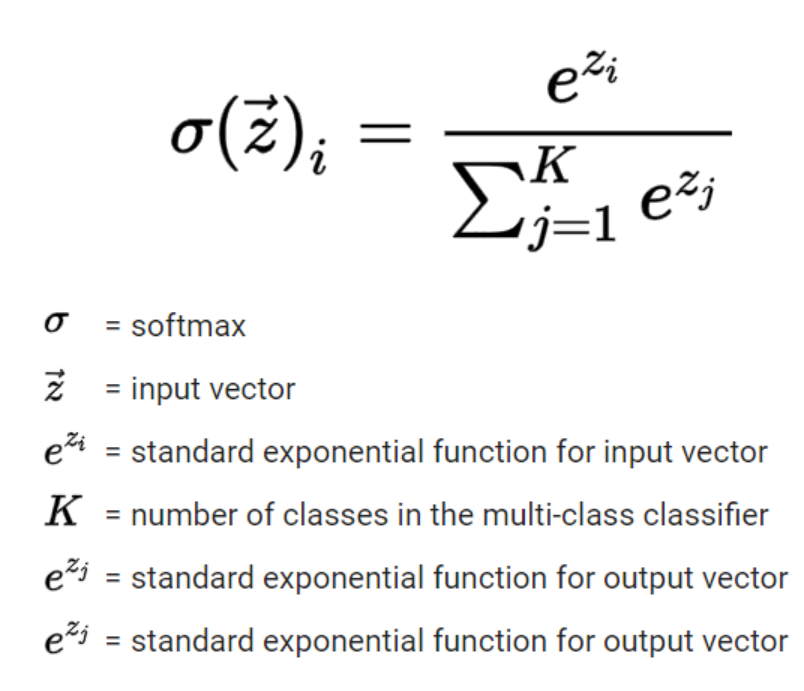

In [16]:
import copy
before_weights = copy.deepcopy(model.weights[0])  # make a copy so we can compare
with tf.GradientTape() as tape:  # gradient tape calculates the gradient (slope) and puts it in tape.gradient
    predictions = model(x)  # put input values into tensorflow model defined above 
    per_sample_losses = tf.keras.losses.sparse_categorical_crossentropy(labels, predictions)
    average_loss = tf.reduce_mean(per_sample_losses)  # Computes the mean of elements across dimensions of a tensor.
gradients = tape.gradient(average_loss, model.weights)  # returns gradients
update_weights(gradients, model.weights)  # subtracts gradient times the learning rate from the model weights
modelout = model(x)  # get the output of the model after one epoch (done with full x dataset, not a mini batch)
print("\n\n",model.weights[0])
print("\n\n",before_weights)



 <Variable path=sequential_1/dense_2/kernel, shape=(3, 64), dtype=float32, value=[[-4.78664935e-01  1.73012689e-01  3.55539054e-01 -2.78526568e+00
  -7.37110078e-01  2.49950901e-01  1.48855597e-01  2.41819978e+00
   3.80640447e-01  1.03268254e+00 -1.19210744e+00 -1.10072970e+00
   1.22958374e+00 -2.24182320e+00 -7.43132651e-01  1.71131253e-01
   4.72567946e-01  3.37599516e-02 -3.69766623e-01  2.63265870e-03
   1.72209430e+00 -8.43883097e-01  7.44453296e-02  9.15306687e-01
  -7.27145493e-01  1.31251264e+00 -1.17435921e-02 -1.12040259e-01
   3.51135969e-01 -3.31285745e-01  1.19364940e-01  6.83807909e-01
   4.79199916e-01  9.65425670e-02 -5.44987977e-01 -1.60456762e-01
   1.44933343e-01 -1.24931037e+00 -7.85239816e-01  2.55053043e+00
   2.64616847e-01  2.36946011e+00  2.44918513e+00 -1.39235398e-02
   3.27455044e+00  7.35649705e-01  8.52879696e-03  1.12366343e+00
  -1.50822520e-01  7.68940508e-01 -1.85558096e-01  7.68805563e-01
   7.03781188e-01 -2.11680126e+00 -8.82612526e-01  7.594254

In [22]:
# calculate output from layer 1
layer1 = np.maximum(x @ np.asarray(model.weights[0]) + np.asarray(model.weights[1]), 0)  # np.maximum does the relu function (np.max() will not work)
# calculate output from layer 2
layer2 = softmax( layer1 @ np.asarray(model.weights[2]) + np.asarray(model.weights[3]))  # softmax for the last layer
np.allclose(layer2,modelout)  # modelout is the output of the model, layer2 is the output of the matrix math.  They are the same.

True

In [18]:
gradients[0]  # show the gradients (slope) as calculated by the gradient tape for first layer
# shape is 3 x 64 (3 features, 64 neurons)

<tf.Tensor: shape=(3, 64), dtype=float32, numpy=
array([[ 0.2899502 , -0.19808547, -0.12850268, -0.23860356, -0.11090293,
        -0.28503904, -0.03806059, -0.03691081, -0.1458114 , -0.20129868,
        -0.05431046,  0.02277676, -0.05242509,  0.07407226,  0.        ,
         0.24701776,  0.02224946,  0.01335711, -0.0092779 , -0.23422588,
         0.42383373, -0.16468725,  0.244738  ,  0.3929695 ,  0.09549409,
         0.13878879,  0.08723113,  0.06196569, -0.09022178, -0.52889717,
        -0.05237511, -0.25994048, -0.22884262, -0.3369726 ,  0.00464112,
         0.0719521 ,  0.1391702 ,  0.2236706 , -0.50142604,  0.04730234,
         0.22077575, -0.27132365, -0.23927   ,  0.23129559,  0.34765404,
         0.16751769, -0.12099682,  0.00175276,  0.39891034, -0.12118626,
        -0.25315893,  0.185262  ,  0.4296502 , -0.35454643, -0.220573  ,
        -0.16348517,  0.3806013 , -0.05222919, -0.12172771,  0.29475188,
         0.0562508 ,  0.04080024,  0.03910779, -0.07980885],
       [ 0.370

The ratio of the before weights to the after update weights is the learning rate, 1e-3 (with rounding)

In [19]:
print((before_weights - model.weights[0])/ gradients[0])

tf.Tensor(
[[0.00099999 0.00099998 0.00100004 0.00100022 0.00100019 0.00100002
  0.00099992 0.00100119 0.00100008 0.00100023 0.0010009  0.00099966
  0.00100052 0.00100102        nan 0.001      0.00100058 0.00100013
  0.00099899 0.001      0.00099989 0.001      0.00099999 0.00100001
  0.00099992 0.00099979 0.001      0.00100001 0.00099989 0.00100001
  0.00100005 0.00099998 0.00100004 0.00100001 0.00100173 0.00100008
  0.00100005 0.00099985 0.00100006 0.00099798 0.001      0.00099999
  0.00100043 0.001      0.00099989 0.00099983 0.001      0.00102019
  0.00099998 0.00099992 0.00099999 0.00099994 0.00099995 0.00099995
  0.00100011 0.00100006 0.00100001 0.0009997  0.00099988 0.00099998
  0.00100028 0.00099998 0.00099982 0.00100002]
 [0.00100007 0.00100024 0.00099991 0.00099993 0.00100038 0.00100031
  0.00100031 0.00099999 0.00100009 0.00099918 0.00099995 0.00100001
  0.00099971 0.00099997        nan 0.00099997 0.00099837 0.0010001
  0.00099422 0.00100009 0.001      0.00100005 0.00100013 0.

### Chapter summary

Tensors form the foundation of modern machine learning systems. They
come in various flavors of dtype, rank, and shape.

You can manipulate numerical tensors via tensor operations (such as
addition, tensor product, or elementwise multiplication), which can be
interpreted as encoding geometric transformations. In general,
everything in deep learning is amenable to a geometric interpretation.

Deep learning models consist of chains of simple tensor operations,
parameterized by weights, which are themselves tensors. The weights of
a model are where its “knowledge” is stored.

Learning means finding a set of values for the model’s weights that
minimizes a loss function for a given set of training data samples and
their corresponding targets.

Learning happens by drawing random batches of data samples and their
targets, and computing the gradient of the model parameters with
respect to the loss on the batch. The model parameters are then moved a
bit (the magnitude of the move is defined by the learning rate) in the
opposite direction from the gradient. This is called mini-batch gradient
descent.

The entire learning process is made possible by the fact that all tensor
operations in neural networks are differentiable, and thus it’s possible to
apply the chain rule of derivation to find the gradient function mapping
the current parameters and current batch of data to a gradient value.
This is called backpropagation.

Two key concepts you’ll see frequently in future chapters are loss and
optimizers. These are the two things you need to define before you begin
feeding data into a model.

The loss is the quantity you’ll attempt to minimize during
training, so it should represent a measure of success for the
task you’re trying to solve.

The optimizer specifies the exact way in which the gradient
of the loss will be used to update parameters: for instance,
it could be the RMSProp optimizer, SGD with momentum,
and so on.